In [1]:
#使用するライブラリをimport
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import lightgbm as lgb

#データセットの読み込み
path = '../data/raw/Milling_Tool_Dataset.csv'
df = pd.read_csv(path)

#訓練用、テスト用、検証用にデータを分割
X = df.drop(["cutting_speed", "feed_rate", "material_hardness", "tool_wear", "RUL"], axis=1)
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#モデルを構築
model=lgb.LGBMRegressor(n_estimators=500,learning_rate=0.05,random_state=42)
model.fit(X_train, y_train) 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [2]:
#モデルを使用して予測
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

#予測結果を評価
from sklearn.metrics import r2_score,mean_absolute_error
print("MAE train:%.3f, MAE test:%.3f"%(mean_absolute_error(y_train, train_predict), mean_absolute_error(y_test, test_predict)))
print("R^2 train:%.3f, R^2 test:%.3f"%(r2_score(y_train, train_predict), r2_score(y_test, test_predict)))

MAE train:0.335, MAE test:2.018
R^2 train:0.989, R^2 test:0.573


In [3]:
#モデルを調整
params = {
    'objective': 'regression',
    'metric': "mae",
    'num_leaves': 31,         # default = 31,
    'learning_rate': 0.1,    # default = 0.1
    'feature_fraction': 1.0,  # default = 1.0
    'bagging_freq': 0,        # default = 0
    'bagging_fraction': 1.0,  # default = 1.0
    'random_state': 0,        # default = None
}
num_round = 100

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

#ハイパーパタメータ調整用のライブラリをimport
import optuna
import optuna.integration.lightgbm as lgb_tuner

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:21:15,596] A new study created in memory with name: no-name-40f08fcf-9952-4888-9f22-d2445413c1cb
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  14%|8     | 1/7 [00:00<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  29%|#7    | 2/7 [00:00<00:01,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  43%|##5   | 3/7 [00:00<00:01,  3.35it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  57%|###4  | 4/7 [00:01<00:00,  3.34it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  71%|####2 | 5/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.924412:  86%|#####1| 6/7 [00:01<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.924412:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.924412:   5%|5          | 1/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.924412:  10%|#1         | 2/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.924412:  15%|#6         | 3/20 [00:01<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  35%|###8       | 7/20 [00:01<00:01,  7.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.852023:  40%|####4      | 8/20 [00:01<00:01,  7.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  45%|####9      | 9/20 [00:02<00:02,  4.66it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.852023:  50%|#####     | 10/20 [00:02<00:02,  4.10it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  60%|######    | 12/20 [00:02<00:02,  3.71it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  65%|######5   | 13/20 [00:03<00:01,  4.15it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  75%|#######5  | 15/20 [00:03<00:01,  3.74it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  80%|########  | 16/20 [00:03<00:00,  4.33it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.852023:  85%|########5 | 17/20 [00:04<00:00,  4.05it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.852023:  90%|######### | 18/20 [00:04<00:00,  3.67it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.852023:  95%|#########5| 19/20 [00:04<00:00,  3.54it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.852023: 100%|##########| 20/20 [00:05<00:00,  3.83it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.852023:  10%|#4            | 1/10 [00:00<00:00, 35.79it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.844676:  60%|########4     | 6/10 [00:00<00:00, 31.52it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.844676:  80%|###########2  | 8/10 [00:00<00:00, 31.00it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.844676: 100%|#############| 10/10 [00:00<00:00, 30.91it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.844676:  33%|3| 1/3 [00:00<00:00, 14.75it/[I 2025-11-03 09:21:23,334] Trial 38 finished with value: 1.8446761182347717 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 29 with value: 1.8446761182347717.
feature_fraction_stage2, val_score: 1.844676: 100%|#| 3/3 [00:00<00:00, 29.63it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

[I 2025-11-03 09:21:23,368] Trial 39 finished with value: 1.8446761182347717 and parameters: {'feature_fraction': 0.92}. Best is trial 29 with value: 1.8446761182347717.
feature_fraction_stage2, val_score: 1.844676: 100%|#| 3/3 [00:00<00:00, 29.45it/
regularization_factors, val_score: 1.844676:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 09:21:23,403] Trial 40 finished with value: 1.8520791020107847 and parameters: {'lambda_l1': 6.0806022527940895, 'lambda_l2': 0.3489041794102678}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:   5%| | 1/20 [00:00<00:00, 29.24it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:   5%| | 1/20 [00:00<00:01, 14.41it/[I 2025-11-03 09:21:23,438] Trial 41 finished with value: 1.8446761183042433 and parameters: {'lambda_l1': 4.513481499887526e-08, 'lambda_l2': 2.5143761111081085e-08}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  10%|1| 2/20 [00:00<00:00, 28.64it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:  20%|2| 4/20 [00:00<00:00, 28.80it/[I 2025-11-03 09:21:23,544] Trial 44 finished with value: 1.8446762839114659 and parameters: {'lambda_l1': 0.00018718178090219048, 'lambda_l2': 0.0001274917068216392}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  25%|2| 5/20 [00:00<00:00, 28.80it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.844676:  30%|3| 6/20 [00:00<00:00, 28.35it/[I 2025-11-03 09:21:23,616] Trial 46 finished with value: 1.8473488738158672 and parameters: {'lambda_l1': 0.12845192354646365, 'lambda_l2': 4.122269002210406}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  35%|3| 7/20 [00:00<00:00, 28.35it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:  35%|3| 7/20 [00:00<00:00, 28.35it/[I 2025-11-03 09:21:23,651] Trial 47 finished with value: 1.8446761209732114 and parameters: {'lambda_l1': 2.3915263085635277e-06, 'lambda_l2': 2.8162824429729254e-06}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  40%|4| 8/20 [00:00<00:00, 28.35it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:  50%|5| 10/20 [00:00<00:00, 28.21it[I 2025-11-03 09:21:23,758] Trial 50 finished with value: 1.844678503066122 and parameters: {'lambda_l1': 0.004763426127246019, 'lambda_l2': 3.1238529903497935e-06}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  55%|5| 11/20 [00:00<00:00, 28.21it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.844676:  60%|6| 12/20 [00:00<00:00, 28.18it[I 2025-11-03 09:21:23,830] Trial 52 finished with value: 1.8446761182509863 and parameters: {'lambda_l1': 1.14407733078979e-08, 'lambda_l2': 1.1473568919671709e-08}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  65%|6| 13/20 [00:00<00:00, 28.18it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:  65%|6| 13/20 [00:00<00:00, 28.18it[I 2025-11-03 09:21:23,865] Trial 53 finished with value: 1.8446761186686211 and parameters: {'lambda_l1': 4.48370574172731e-07, 'lambda_l2': 5.916427897745929e-07}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  70%|7| 14/20 [00:00<00:00, 28.18it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:  80%|8| 16/20 [00:00<00:00, 28.15it[I 2025-11-03 09:21:23,973] Trial 56 finished with value: 1.8446777226429452 and parameters: {'lambda_l1': 6.724624981793672e-06, 'lambda_l2': 0.0028071093954907395}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  85%|8| 17/20 [00:00<00:00, 28.15it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.844676:  90%|9| 18/20 [00:00<00:00, 28.32it[I 2025-11-03 09:21:24,034] Trial 58 finished with value: 1.8446767321966444 and parameters: {'lambda_l1': 0.0012278111113626562, 'lambda_l2': 1.6886652956919222e-08}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676:  95%|9| 19/20 [00:00<00:00, 28.32it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.844676:  95%|9| 19/20 [00:00<00:00, 28.32it[I 2025-11-03 09:21:24,070] Trial 59 finished with value: 1.8446766020797034 and parameters: {'lambda_l1': 5.2496716679637544e-08, 'lambda_l2': 0.0008489381234294817}. Best is trial 29 with value: 1.8446761182347717.
regularization_factors, val_score: 1.844676: 100%|#| 20/20 [00:00<00:00, 28.50it
min_child_samples, val_score: 1.844676:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.844374:  60%|###  | 3/5 [00:00<00:00, 29.09it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

min_child_samples, val_score: 1.844374: 100%|#####| 5/5 [00:00<00:00, 29.01it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 1, 'bagging_fraction': 0.9511593721357787, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'min_child_samples': 5}


In [4]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train  =mean_absolute_error(y_train, train_predict)
MAE_test  =mean_absolute_error(y_test, test_predict)
R2_train = r2_score(y_train, train_predict)
R2_test = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train, MAE_test))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train, R2_test))

MAE train:1.806, MAE test:1.844
R^2 train:0.693, R^2 test:0.640


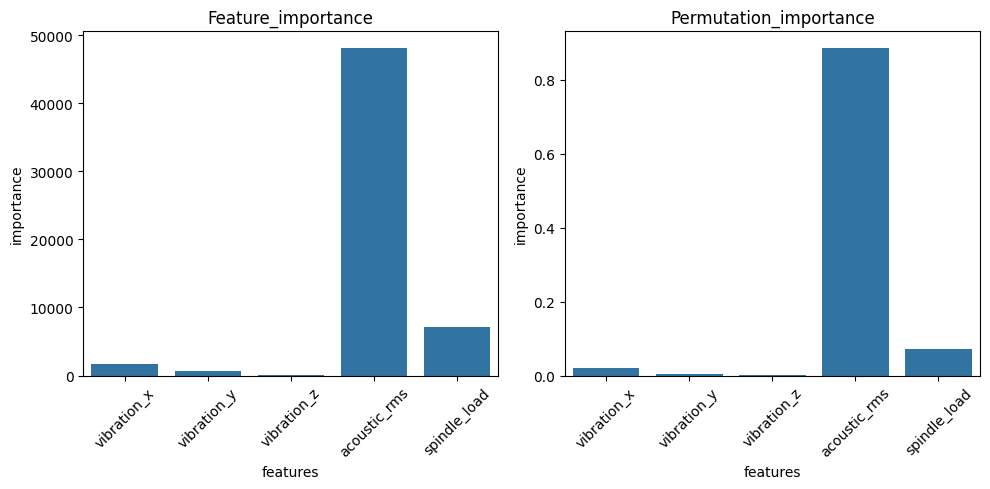

In [5]:
#各特徴量のモデル作成時の寄与を評価
feature_importance=pd.DataFrame(zip(X.columns, adjusted_model.feature_importance(importance_type='gain')), columns=['features', 'importance'])

#各特徴量のモデルの予測精度への寄与を評価
from sklearn.inspection import permutation_importance
regressor_model = lgb.LGBMRegressor()
regressor_model._Booster = adjusted_model
regressor_model._n_features = X_test.shape[1]
regressor_model.fitted_ = True
result = permutation_importance(regressor_model, X_test, y_test, n_repeats=10, random_state=42)
purmutation_importance=pd.DataFrame(zip(X.columns, result['importances'].mean(axis=1)), columns=['features', 'importance'])

#特徴量の重要性を表示
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(feature_importance, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Feature_importance')
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(purmutation_importance, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Permutation_importance')
plt.tight_layout()

計算負荷が軽く高精度なLightGBMを使用し、生データの各センサのデータより"tool_wear"を予測。

評価値はR^2(決定係数)=0.613　　MAE(平均絶対誤差)=1.885

また特徴量の重要度評価では、2つの指標はどちらも同じ傾向。"acoustic_rms"の寄与度が非常に大きく評価されていて、続いて"spindle_load", "vibration_x"となっている。これは、eda.ipynbで確認した各センサデータの"tool_wear"との相関係数の値とも矛盾しない。

次に、複数の加工データから移動平均を取ったデータセットでトライする。

In [6]:
#20行のデータの移動平均を使用したデータでトライ
path_avg = '../data/processed/mv_avg_20.csv'
df = pd.read_csv(path_avg)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:21:33,936] A new study created in memory with name: no-name-4c9c071e-a091-4269-85ad-d10f49f6a1d4
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  14%|8     | 1/7 [00:00<00:01,  3.20it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  29%|#7    | 2/7 [00:00<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  43%|##5   | 3/7 [00:00<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  57%|###4  | 4/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  71%|####2 | 5/7 [00:01<00:00,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.271400:  86%|#####1| 6/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.271400:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:   5%|5          | 1/20 [00:00<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  10%|#1         | 2/20 [00:00<00:06,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  15%|#6         | 3/20 [00:01<00:06,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  25%|##7        | 5/20 [00:01<00:05,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

num_leaves, val_score: 0.265909:  30%|###3       | 6/20 [00:01<00:03,  3.69it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:  35%|###8       | 7/20 [00:02<00:03,  3.37it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  40%|####4      | 8/20 [00:02<00:03,  3.18it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  45%|####9      | 9/20 [00:02<00:03,  3.08it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  55%|#####5    | 11/20 [00:03<00:02,  3.71it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true

num_leaves, val_score: 0.265909:  60%|######    | 12/20 [00:03<00:02,  3.36it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  65%|######5   | 13/20 [00:04<00:02,  3.15it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  70%|#######   | 14/20 [00:04<00:01,  3.02it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:  75%|#######5  | 15/20 [00:04<00:01,  2.93it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  80%|########  | 16/20 [00:05<00:01,  2.87it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  85%|########5 | 17/20 [00:05<00:01,  2.91it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.265909:  90%|######### | 18/20 [00:05<00:00,  2.86it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.265909:  95%|#########5| 19/20 [00:06<00:00,  2.82it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.265909:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.265909:  10%|#4            | 1/10 [00:00<00:02,  3.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.265909:  20%|##8           | 2/10 [00:00<00:01,  4.36it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262:  30%|####2         | 3/10 [00:00<00:01,  3.53it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.262262:  40%|#####6        | 4/10 [00:01<00:01,  3.14it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262:  50%|#######       | 5/10 [00:01<00:01,  3.43it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262:  60%|########4     | 6/10 [00:01<00:01,  3.17it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262:  70%|#########7    | 7/10 [00:02<00:01,  2.99it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262:  80%|###########2  | 8/10 [00:02<00:00,  3.07it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262:  90%|############6 | 9/10 [00:02<00:00,  3.08it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.262262: 100%|#############| 10/10 [00:03<00:00,  3.25it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.262262:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

feature_fraction_stage2, val_score: 0.262262:  33%|3| 1/3 [00:00<00:00,  2.75it/[I 2025-11-03 09:21:46,081] Trial 37 finished with value: 0.26226155596526873 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 29 with value: 0.26226155596526873.
feature_fraction_stage2, val_score: 0.262262:  33%|3| 1/3 [00:00<00:00,  2.75it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

feature_fraction_stage2, val_score: 0.262262:  67%|6| 2/3 [00:00<00:00,  2.76it/[I 2025-11-03 09:21:46,443] Trial 38 finished with value: 0.26226155596526873 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 29 with value: 0.26226155596526873.
feature_fraction_stage2, val_score: 0.262262:  67%|6| 2/3 [00:00<00:00,  2.76it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.262262: 100%|#| 3/3 [00:01<00:00,  2.78it/[I 2025-11-03 09:21:46,800] Trial 39 finished with value: 0.26226155596526873 and parameters: {'feature_fraction': 0.92}. Best is trial 29 with value: 0.26226155596526873.
feature_fraction_stage2, val_score: 0.262262: 100%|#| 3/3 [00:01<00:00,  2.77it/


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.262262:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.262262:   5%| | 1/20 [00:00<00:06,  2.76it/[I 2025-11-03 09:21:47,164] Trial 40 finished with value: 0.26226156505080356 and parameters: {'lambda_l1': 1.1408500775991814e-06, 'lambda_l2': 1.3269951837905726e-05}. Best is trial 29 with value: 0.26226155596526873.
regularization_factors, val_score: 0.262262:   5%| | 1/20 [00:00<00:06,  2.76it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.262262:  10%|1| 2/20 [00:00<00:06,  2.75it/[I 2025-11-03 09:21:47,527] Trial 41 finished with value: 0.26226156238077564 and parameters: {'lambda_l1': 6.007002843677689e-07, 'lambda_l2': 1.0462972364125096e-05}. Best is trial 29 with value: 0.26226155596526873.
regularization_factors, val_score: 0.262262:  10%|1| 2/20 [00:00<00:06,  2.75it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

regularization_factors, val_score: 0.262262:  15%|1| 3/20 [00:01<00:06,  2.75it/[I 2025-11-03 09:21:47,890] Trial 42 finished with value: 0.2622615560390958 and parameters: {'lambda_l1': 4.742752171290162e-08, 'lambda_l2': 1.0294131046329347e-08}. Best is trial 29 with value: 0.26226155596526873.
regularization_factors, val_score: 0.262262:  15%|1| 3/20 [00:01<00:06,  2.75it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.262262:  20%|2| 4/20 [00:01<00:05,  3.18it/[I 2025-11-03 09:21:48,130] Trial 43 finished with value: 0.31303762389206713 and parameters: {'lambda_l1': 2.33831908775313, 'lambda_l2': 7.9980496897433175}. Best is trial 29 with value: 0.26226155596526873.
regularization_factors, val_score: 0.262262:  20%|2| 4/20 [00:01<00:05,  3.18it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 secon

regularization_factors, val_score: 0.262262:  25%|2| 5/20 [00:01<00:04,  3.01it/[I 2025-11-03 09:21:48,494] Trial 44 finished with value: 0.26226155593848893 and parameters: {'lambda_l1': 1.1137823396470437e-08, 'lambda_l2': 1.033554121353665e-08}. Best is trial 44 with value: 0.26226155593848893.
regularization_factors, val_score: 0.262262:  25%|2| 5/20 [00:01<00:04,  3.01it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.262262:  30%|3| 6/20 [00:02<00:04,  2.91it/[I 2025-11-03 09:21:48,861] Trial 45 finished with value: 0.2647852775567393 and parameters: {'lambda_l1': 0.004543779748725288, 'lambda_l2': 1.0220884994901251e-08}. Best is trial 44 with value: 0.26226155593848893.
regularization_factors, val_score: 0.262262:  30%|3| 6/20 [00:02<00:04,  2.91it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

regularization_factors, val_score: 0.262262:  35%|3| 7/20 [00:02<00:04,  2.85it/[I 2025-11-03 09:21:49,225] Trial 46 finished with value: 0.26742633173663427 and parameters: {'lambda_l1': 0.000174447490116263, 'lambda_l2': 0.035599717443657294}. Best is trial 44 with value: 0.26226155593848893.
regularization_factors, val_score: 0.262262:  35%|3| 7/20 [00:02<00:04,  2.85it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.262262:  40%|4| 8/20 [00:02<00:04,  2.82it/[I 2025-11-03 09:21:49,589] Trial 47 finished with value: 0.2622621158572334 and parameters: {'lambda_l1': 0.00022265335710027398, 'lambda_l2': 2.51239685442935e-06}. Best is trial 44 with value: 0.26226155593848893.
regularization_factors, val_score: 0.262262:  40%|4| 8/20 [00:02<00:04,  2.82it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.261644:  45%|4| 9/20 [00:03<00:03,  2.80it/[I 2025-11-03 09:21:49,952] Trial 48 finished with value: 0.26164422655809494 and parameters: {'lambda_l1': 1.1205257649566477e-08, 'lambda_l2': 0.003284286539669579}. Best is trial 48 with value: 0.26164422655809494.
regularization_factors, val_score: 0.261644:  45%|4| 9/20 [00:03<00:03,  2.80it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

regularization_factors, val_score: 0.261644:  50%|5| 10/20 [00:03<00:03,  2.78it[I 2025-11-03 09:21:50,317] Trial 49 finished with value: 0.2651230491462214 and parameters: {'lambda_l1': 1.3552487845289152e-08, 'lambda_l2': 0.011615391083276527}. Best is trial 48 with value: 0.26164422655809494.
regularization_factors, val_score: 0.261644:  50%|5| 10/20 [00:03<00:03,  2.78it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.261644:  55%|5| 11/20 [00:03<00:03,  2.77it[I 2025-11-03 09:21:50,680] Trial 50 finished with value: 0.26164361245675105 and parameters: {'lambda_l1': 2.865655822605657e-06, 'lambda_l2': 0.002387084906054876}. Best is trial 50 with value: 0.26164361245675105.
regularization_factors, val_score: 0.261644:  55%|5| 11/20 [00:03<00:03,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 0.261644:  60%|6| 12/20 [00:04<00:02,  2.77it[I 2025-11-03 09:21:51,043] Trial 51 finished with value: 0.2616444027714575 and parameters: {'lambda_l1': 1.1139621141316984e-06, 'lambda_l2': 0.0035258942754320373}. Best is trial 50 with value: 0.26164361245675105.
regularization_factors, val_score: 0.261644:  60%|6| 12/20 [00:04<00:02,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.261644:  65%|6| 13/20 [00:04<00:02,  2.77it[I 2025-11-03 09:21:51,401] Trial 52 finished with value: 0.2616443011074903 and parameters: {'lambda_l1': 1.132265562861967e-06, 'lambda_l2': 0.003380587385114815}. Best is trial 50 with value: 0.26164361245675105.
regularization_factors, val_score: 0.261644:  65%|6| 13/20 [00:04<00:02,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.261644:  70%|7| 14/20 [00:04<00:02,  2.78it[I 2025-11-03 09:21:51,758] Trial 53 finished with value: 0.2616441788379274 and parameters: {'lambda_l1': 1.4787535670351092e-06, 'lambda_l2': 0.003204803147399388}. Best is trial 50 with value: 0.26164361245675105.
regularization_factors, val_score: 0.261644:  70%|7| 14/20 [00:04<00:02,  2.78it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.261644:  75%|7| 15/20 [00:05<00:01,  2.78it[I 2025-11-03 09:21:52,118] Trial 54 finished with value: 0.2616443151077382 and parameters: {'lambda_l1': 2.472778443403071e-06, 'lambda_l2': 0.003390143860450119}. Best is trial 50 with value: 0.26164361245675105.
regularization_factors, val_score: 0.261644:  75%|7| 15/20 [00:05<00:01,  2.78it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.261644:  80%|8| 16/20 [00:05<00:01,  2.77it[I 2025-11-03 09:21:52,480] Trial 55 finished with value: 0.26164445401491326 and parameters: {'lambda_l1': 4.1709374600277235e-06, 'lambda_l2': 0.0035735870334573897}. Best is trial 50 with value: 0.26164361245675105.
regularization_factors, val_score: 0.261644:  80%|8| 16/20 [00:05<00:01,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.261643:  85%|8| 17/20 [00:06<00:01,  2.77it[I 2025-11-03 09:21:52,840] Trial 56 finished with value: 0.26164273764211265 and parameters: {'lambda_l1': 5.438151805756676e-06, 'lambda_l2': 0.001121573126252767}. Best is trial 56 with value: 0.26164273764211265.
regularization_factors, val_score: 0.261643:  85%|8| 17/20 [00:06<00:01,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.261643:  90%|9| 18/20 [00:06<00:00,  2.77it[I 2025-11-03 09:21:53,203] Trial 57 finished with value: 0.26226183641917034 and parameters: {'lambda_l1': 1.0372217924526135e-05, 'lambda_l2': 0.000518210156948975}. Best is trial 56 with value: 0.26164273764211265.
regularization_factors, val_score: 0.261643:  90%|9| 18/20 [00:06<00:00,  2.77it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-ch

regularization_factors, val_score: 0.261643:  95%|9| 19/20 [00:06<00:00,  2.77it[I 2025-11-03 09:21:53,562] Trial 58 finished with value: 0.2622618834659638 and parameters: {'lambda_l1': 2.565052184080004e-05, 'lambda_l2': 0.0005348344875551895}. Best is trial 56 with value: 0.26164273764211265.
regularization_factors, val_score: 0.261643:  95%|9| 19/20 [00:06<00:00,  2.77it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.261643: 100%|#| 20/20 [00:07<00:00,  2.77it[I 2025-11-03 09:21:53,926] Trial 59 finished with value: 0.26792298511523277 and parameters: {'lambda_l1': 2.2782402902250883e-07, 'lambda_l2': 0.06449296305290678}. Best is trial 56 with value: 0.26164273764211265.
regularization_factors, val_score: 0.261643: 100%|#| 20/20 [00:07<00:00,  2.81it


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


min_child_samples, val_score: 0.261643:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.261643:  20%|#    | 1/5 [00:00<00:00,  6.43it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.261643:  40%|##   | 2/5 [00:00<00:00,  6.43it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.239989:  60%|###  | 3/5 [00:00<00:00,  3.02it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.239989:  80%|#### | 4/5 [00:01<00:00,  2.45it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.239989: 100%|#####| 5/5 [00:01<00:00,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [7]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_20  =mean_absolute_error(y_train, train_predict)
MAE_test_20  =mean_absolute_error(y_test, test_predict)
R2_train_20 = r2_score(y_train, train_predict)
R2_test_20 = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_20, MAE_test_20))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_20, R2_test_20))

MAE train:0.032, MAE test:0.240
R^2 train:1.000, R^2 test:0.991


In [8]:
#10行のデータの移動平均を使用したデータでトライ
path_avg_10 = '../data/processed/mv_avg_10.csv'
df = pd.read_csv(path_avg_10)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:21:59,974] A new study created in memory with name: no-name-21ea5ded-beca-4c3b-b0f5-570873d7e6f5
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  14%|8     | 1/7 [00:00<00:02,  2.94it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  29%|#7    | 2/7 [00:00<00:01,  3.05it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  43%|##5   | 3/7 [00:00<00:01,  3.11it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  57%|###4  | 4/7 [00:01<00:00,  3.12it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  71%|####2 | 5/7 [00:01<00:00,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.576977:  86%|#####1| 6/7 [00:01<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.576977:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.576977:   5%|5          | 1/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  10%|#1         | 2/20 [00:00<00:06,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  15%|#6         | 3/20 [00:01<00:06,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  25%|##7        | 5/20 [00:01<00:03,  4.72it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 0.576977:  30%|###3       | 6/20 [00:01<00:03,  3.86it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  35%|###8       | 7/20 [00:02<00:03,  3.41it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.576977:  40%|####4      | 8/20 [00:02<00:03,  3.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  45%|####9      | 9/20 [00:02<00:03,  3.03it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  50%|#####     | 10/20 [00:03<00:03,  2.96it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  55%|#####5    | 11/20 [00:03<00:03,  2.90it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

num_leaves, val_score: 0.576977:  60%|######    | 12/20 [00:03<00:02,  2.85it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  65%|######5   | 13/20 [00:04<00:02,  2.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  70%|#######   | 14/20 [00:04<00:02,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  75%|#######5  | 15/20 [00:04<00:01,  3.54it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.576977:  80%|########  | 16/20 [00:05<00:01,  3.28it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  85%|########5 | 17/20 [00:05<00:00,  3.13it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  90%|######### | 18/20 [00:05<00:00,  3.04it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.576977:  95%|#########5| 19/20 [00:06<00:00,  3.04it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.576977: 100%|##########| 20/20 [00:06<00:00,  3.11it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.576977:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.576977:  10%|#4            | 1/10 [00:00<00:02,  4.41it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

bagging, val_score: 0.576977:  30%|####2         | 3/10 [00:00<00:01,  5.45it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.576977:  40%|#####6        | 4/10 [00:00<00:01,  4.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:  50%|#######       | 5/10 [00:01<00:01,  3.76it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.576977:  60%|########4     | 6/10 [00:01<00:01,  3.78it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


bagging, val_score: 0.576977:  70%|#########7    | 7/10 [00:01<00:00,  3.62it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

bagging, val_score: 0.576977:  80%|###########2  | 8/10 [00:02<00:00,  3.61it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.576977:  90%|############6 | 9/10 [00:02<00:00,  3.45it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


bagging, val_score: 0.576977: 100%|#############| 10/10 [00:02<00:00,  3.75it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


feature_fraction_stage2, val_score: 0.576977:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.576977:  33%|3| 1/3 [00:00<00:00,  3.31it/[I 2025-11-03 09:22:11,545] Trial 37 finished with value: 0.5769768184781733 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 0 with value: 0.5769768184781733.
feature_fraction_stage2, val_score: 0.576977:  33%|3| 1/3 [00:00<00:00,  3.31it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.576977:  67%|6| 2/3 [00:00<00:00,  3.30it/[I 2025-11-03 09:22:11,849] Trial 38 finished with value: 0.5769768184781733 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 0 with value: 0.5769768184781733.
feature_fraction_stage2, val_score: 0.576977:  67%|6| 2/3 [00:00<00:00,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.576977: 100%|#| 3/3 [00:00<00:00,  3.30it/[I 2025-11-03 09:22:12,151] Trial 39 finished with value: 0.5769768184781733 and parameters: {'feature_fraction': 0.92}. Best is trial 0 with value: 0.5769768184781733.
feature_fraction_stage2, val_score: 0.576977: 100%|#| 3/3 [00:00<00:00,  3.30it/
regularization_factors, val_score: 0.576977:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:   5%| | 1/20 [00:00<00:05,  3.24it/[I 2025-11-03 09:22:12,461] Trial 40 finished with value: 0.5900868271048665 and parameters: {'lambda_l1': 0.003927072557742879, 'lambda_l2': 0.05002989605531187}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:   5%| | 1/20 [00:00<00:05,  3.24it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  10%|1| 2/20 [00:00<00:05,  3.24it/[I 2025-11-03 09:22:12,770] Trial 41 finished with value: 0.5769768187309225 and parameters: {'lambda_l1': 6.181620549450516e-08, 'lambda_l2': 2.0801946084569072e-08}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:  10%|1| 2/20 [00:00<00:05,  3.24it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

regularization_factors, val_score: 0.576977:  15%|1| 3/20 [00:00<00:04,  3.45it/[I 2025-11-03 09:22:13,037] Trial 42 finished with value: 0.5999696360843776 and parameters: {'lambda_l1': 2.1777530879759346, 'lambda_l2': 5.483192394288843}. Best is trial 0 with value: 0.5769768184781733.
regularization_factors, val_score: 0.576977:  15%|1| 3/20 [00:00<00:04,  3.45it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  20%|2| 4/20 [00:01<00:04,  3.37it/[I 2025-11-03 09:22:13,345] Trial 43 finished with value: 0.5769768172749605 and parameters: {'lambda_l1': 2.5790095930220707e-08, 'lambda_l2': 8.814253620069689e-07}. Best is trial 43 with value: 0.5769768172749605.
regularization_factors, val_score: 0.576977:  20%|2| 4/20 [00:01<00:04,  3.37it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  25%|2| 5/20 [00:01<00:04,  3.40it/[I 2025-11-03 09:22:13,634] Trial 44 finished with value: 0.5769768177128582 and parameters: {'lambda_l1': 1.2211198255590549e-08, 'lambda_l2': 5.61287775278548e-07}. Best is trial 43 with value: 0.5769768172749605.
regularization_factors, val_score: 0.576977:  25%|2| 5/20 [00:01<00:04,  3.40it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  30%|3| 6/20 [00:01<00:04,  3.34it/[I 2025-11-03 09:22:13,944] Trial 45 finished with value: 0.5769768178919681 and parameters: {'lambda_l1': 1.2201527921467864e-08, 'lambda_l2': 4.685409156312567e-07}. Best is trial 43 with value: 0.5769768172749605.
regularization_factors, val_score: 0.576977:  30%|3| 6/20 [00:01<00:04,  3.34it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  35%|3| 7/20 [00:02<00:03,  3.32it/[I 2025-11-03 09:22:14,248] Trial 46 finished with value: 0.5769768179509244 and parameters: {'lambda_l1': 2.9421572848409203e-08, 'lambda_l2': 3.9811532987348697e-07}. Best is trial 43 with value: 0.5769768172749605.
regularization_factors, val_score: 0.576977:  35%|3| 7/20 [00:02<00:03,  3.32it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  40%|4| 8/20 [00:02<00:03,  3.34it/[I 2025-11-03 09:22:14,544] Trial 47 finished with value: 0.5769768179510797 and parameters: {'lambda_l1': 2.0134217052228313e-08, 'lambda_l2': 3.810599263763341e-07}. Best is trial 43 with value: 0.5769768172749605.
regularization_factors, val_score: 0.576977:  40%|4| 8/20 [00:02<00:03,  3.34it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  45%|4| 9/20 [00:02<00:03,  3.30it/[I 2025-11-03 09:22:14,855] Trial 48 finished with value: 0.5769768179519686 and parameters: {'lambda_l1': 1.4499400364162502e-08, 'lambda_l2': 4.1276621797226655e-07}. Best is trial 43 with value: 0.5769768172749605.
regularization_factors, val_score: 0.576977:  45%|4| 9/20 [00:02<00:03,  3.30it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  50%|5| 10/20 [00:03<00:03,  3.29it[I 2025-11-03 09:22:15,160] Trial 49 finished with value: 0.5769768150850572 and parameters: {'lambda_l1': 1.8567300592462555e-08, 'lambda_l2': 1.8712484016200051e-06}. Best is trial 49 with value: 0.5769768150850572.
regularization_factors, val_score: 0.576977:  50%|5| 10/20 [00:03<00:03,  3.29it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  55%|5| 11/20 [00:03<00:02,  3.28it[I 2025-11-03 09:22:15,468] Trial 50 finished with value: 0.5769768114091308 and parameters: {'lambda_l1': 1.1674873252575034e-08, 'lambda_l2': 3.912319493876683e-06}. Best is trial 50 with value: 0.5769768114091308.
regularization_factors, val_score: 0.576977:  55%|5| 11/20 [00:03<00:02,  3.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  60%|6| 12/20 [00:03<00:02,  3.25it[I 2025-11-03 09:22:15,781] Trial 51 finished with value: 0.576976814211682 and parameters: {'lambda_l1': 1.2392506830188559e-08, 'lambda_l2': 2.599878813761162e-06}. Best is trial 50 with value: 0.5769768114091308.
regularization_factors, val_score: 0.576977:  60%|6| 12/20 [00:03<00:02,  3.25it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  65%|6| 13/20 [00:03<00:02,  3.24it[I 2025-11-03 09:22:16,094] Trial 52 finished with value: 0.5769768084735474 and parameters: {'lambda_l1': 1.0241452769325662e-08, 'lambda_l2': 5.797026586819188e-06}. Best is trial 52 with value: 0.5769768084735474.
regularization_factors, val_score: 0.576977:  65%|6| 13/20 [00:03<00:02,  3.24it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  70%|7| 14/20 [00:04<00:01,  3.23it[I 2025-11-03 09:22:16,405] Trial 53 finished with value: 0.5769767803652314 and parameters: {'lambda_l1': 1.048636500718263e-08, 'lambda_l2': 2.2054246727009475e-05}. Best is trial 53 with value: 0.5769767803652314.
regularization_factors, val_score: 0.576977:  70%|7| 14/20 [00:04<00:01,  3.23it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  75%|7| 15/20 [00:04<00:01,  3.22it[I 2025-11-03 09:22:16,717] Trial 54 finished with value: 0.5769767508274093 and parameters: {'lambda_l1': 1.0738402163007013e-06, 'lambda_l2': 3.8857200147275744e-05}. Best is trial 54 with value: 0.5769767508274093.
regularization_factors, val_score: 0.576977:  75%|7| 15/20 [00:04<00:01,  3.22it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  80%|8| 16/20 [00:04<00:01,  3.22it[I 2025-11-03 09:22:17,028] Trial 55 finished with value: 0.5769767406012398 and parameters: {'lambda_l1': 2.2711280620334105e-06, 'lambda_l2': 4.4692758438274944e-05}. Best is trial 55 with value: 0.5769767406012398.
regularization_factors, val_score: 0.576977:  80%|8| 16/20 [00:04<00:01,  3.22it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  85%|8| 17/20 [00:05<00:00,  3.23it[I 2025-11-03 09:22:17,334] Trial 56 finished with value: 0.5769766764884305 and parameters: {'lambda_l1': 2.421400068426047e-06, 'lambda_l2': 8.18674899128381e-05}. Best is trial 56 with value: 0.5769766764884305.
regularization_factors, val_score: 0.576977:  85%|8| 17/20 [00:05<00:00,  3.23it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  90%|9| 18/20 [00:05<00:00,  3.24it[I 2025-11-03 09:22:17,643] Trial 57 finished with value: 0.5769766345017886 and parameters: {'lambda_l1': 3.368941247593111e-06, 'lambda_l2': 0.00010579996233608233}. Best is trial 57 with value: 0.5769766345017886.
regularization_factors, val_score: 0.576977:  90%|9| 18/20 [00:05<00:00,  3.24it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576977:  95%|9| 19/20 [00:05<00:00,  3.22it[I 2025-11-03 09:22:17,955] Trial 58 finished with value: 0.5769765492974064 and parameters: {'lambda_l1': 5.3958110258875674e-06, 'lambda_l2': 0.00015471785360851925}. Best is trial 58 with value: 0.5769765492974064.
regularization_factors, val_score: 0.576977:  95%|9| 19/20 [00:05<00:00,  3.22it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.576976: 100%|#| 20/20 [00:06<00:00,  3.23it[I 2025-11-03 09:22:18,265] Trial 59 finished with value: 0.5769764684340025 and parameters: {'lambda_l1': 3.020189244862563e-06, 'lambda_l2': 0.0002003308576739346}. Best is trial 59 with value: 0.5769764684340025.
regularization_factors, val_score: 0.576976: 100%|#| 20/20 [00:06<00:00,  3.27it
min_child_samples, val_score: 0.576976:  20%|#    | 1/5 [00:00<00:00,  6.40it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.576976:  40%|##   | 2/5 [00:00<00:00,  6.40it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.572093:  60%|###  | 3/5 [00:00<00:00,  5.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.572093:  80%|#### | 4/5 [00:00<00:00,  4.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.572093: 100%|#####| 5/5 [00:01<00:00,  4.27it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 31, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 0, 'bagging_fraction': 1.0, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 3.020189244862563e-06, 'lambda_l2': 0.0002003308576739346, 'min_child_samples': 5}


In [9]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_10  =mean_absolute_error(y_train, train_predict)
MAE_test_10  =mean_absolute_error(y_test, test_predict)
R2_train_10 = r2_score(y_train, train_predict)
R2_test_10 = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_10, MAE_test_10))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_10, R2_test_10))

MAE train:0.149, MAE test:0.572
R^2 train:0.998, R^2 test:0.960


In [10]:
#5行のデータの移動平均を使用したデータでトライ
path_avg_5 = '../data/processed/mv_avg_5.csv'
df = pd.read_csv(path_avg_5)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:22:24,745] A new study created in memory with name: no-name-348714e9-e567-4b90-9f0e-f0527af027fa
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.922167:  14%|8     | 1/7 [00:00<00:01,  3.15it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.922167:  29%|#7    | 2/7 [00:00<00:01,  3.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.922167:  43%|##5   | 3/7 [00:00<00:01,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.917595:  57%|###4  | 4/7 [00:01<00:00,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.917595:  71%|####2 | 5/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.917595:  86%|#####1| 6/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.917595:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.917595:   5%|5          | 1/20 [00:00<00:06,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.917595:  10%|#1         | 2/20 [00:00<00:06,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.909525:  20%|##2        | 4/20 [00:01<00:05,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  35%|###8       | 7/20 [00:01<00:02,  4.87it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

num_leaves, val_score: 0.895573:  40%|####4      | 8/20 [00:01<00:02,  5.88it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.895573:  45%|####9      | 9/20 [00:02<00:02,  4.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  50%|#####     | 10/20 [00:02<00:02,  4.10it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  55%|#####5    | 11/20 [00:02<00:02,  3.66it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  60%|######    | 12/20 [00:03<00:02,  3.42it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.895573:  65%|######5   | 13/20 [00:03<00:02,  3.22it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  70%|#######   | 14/20 [00:03<00:01,  3.08it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  75%|#######5  | 15/20 [00:04<00:01,  3.02it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.895573:  80%|########  | 16/20 [00:04<00:01,  2.95it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  85%|########5 | 17/20 [00:04<00:00,  3.16it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.895573:  90%|######### | 18/20 [00:05<00:00,  3.04it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.895573:  95%|#########5| 19/20 [00:05<00:00,  3.15it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 0.895573: 100%|##########| 20/20 [00:05<00:00,  3.44it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.895573:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  10%|#4            | 1/10 [00:00<00:00,  9.19it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  20%|##8           | 2/10 [00:00<00:00,  9.01it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  30%|####2         | 3/10 [00:00<00:00,  8.98it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  40%|#####6        | 4/10 [00:00<00:00,  8.83it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  50%|#######       | 5/10 [00:00<00:00,  8.78it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  60%|########4     | 6/10 [00:00<00:00,  8.68it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  70%|#########7    | 7/10 [00:00<00:00,  8.72it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  80%|###########2  | 8/10 [00:00<00:00,  8.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 0.895573:  90%|############6 | 9/10 [00:01<00:00,  8.90it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573:   0%|       | 0/6 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573:  17%|1| 1/6 [00:00<00:00,  8.99it/[I 2025-11-03 09:22:33,949] Trial 37 finished with value: 0.8955725675441958 and parameters: {'feature_fraction': 0.748}. Best is trial 11 with value: 0.8955725675441958.
feature_fraction_stage2, val_score: 0.895573:  17%|1| 1/6 [00:00<00:00,  8.99it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573:  33%|3| 2/6 [00:00<00:00,  9.02it/[I 2025-11-03 09:22:34,060] Trial 38 finished with value: 0.9266390473816823 and parameters: {'feature_fraction': 0.652}. Best is trial 11 with value: 0.8955725675441958.
feature_fraction_stage2, val_score: 0.895573:  33%|3| 2/6 [00:00<00:00,  9.02it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573:  50%|5| 3/6 [00:00<00:00,  9.00it/[I 2025-11-03 09:22:34,171] Trial 39 finished with value: 0.8955725675441958 and parameters: {'feature_fraction': 0.7799999999999999}. Best is trial 11 with value: 0.8955725675441958.
feature_fraction_stage2, val_score: 0.895573:  50%|5| 3/6 [00:00<00:00,  9.00it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573:  67%|6| 4/6 [00:00<00:00,  9.03it/[I 2025-11-03 09:22:34,282] Trial 40 finished with value: 0.9266390473816823 and parameters: {'feature_fraction': 0.62}. Best is trial 11 with value: 0.8955725675441958.
feature_fraction_stage2, val_score: 0.895573:  67%|6| 4/6 [00:00<00:00,  9.03it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573:  83%|8| 5/6 [00:00<00:00,  9.04it/[I 2025-11-03 09:22:34,392] Trial 41 finished with value: 0.9266390473816823 and parameters: {'feature_fraction': 0.6839999999999999}. Best is trial 11 with value: 0.8955725675441958.
feature_fraction_stage2, val_score: 0.895573:  83%|8| 5/6 [00:00<00:00,  9.04it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 0.895573: 100%|#| 6/6 [00:00<00:00,  9.03it/[I 2025-11-03 09:22:34,503] Trial 42 finished with value: 0.8955725675441958 and parameters: {'feature_fraction': 0.716}. Best is trial 11 with value: 0.8955725675441958.
feature_fraction_stage2, val_score: 0.895573: 100%|#| 6/6 [00:00<00:00,  9.02it/
regularization_factors, val_score: 0.895573:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:   5%| | 1/20 [00:00<00:02,  8.92it/[I 2025-11-03 09:22:34,616] Trial 43 finished with value: 0.8955722367601291 and parameters: {'lambda_l1': 0.0002563860664810112, 'lambda_l2': 4.655596921554127e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:   5%| | 1/20 [00:00<00:02,  8.92it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  10%|1| 2/20 [00:00<00:01,  9.16it/[I 2025-11-03 09:22:34,723] Trial 44 finished with value: 0.8955722732253218 and parameters: {'lambda_l1': 0.0002279830203878376, 'lambda_l2': 2.376549675480626e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:  10%|1| 2/20 [00:00<00:01,  9.16it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  15%|1| 3/20 [00:00<00:01,  9.09it/[I 2025-11-03 09:22:34,834] Trial 45 finished with value: 0.8955723120704716 and parameters: {'lambda_l1': 0.00019800560573280383, 'lambda_l2': 2.429475722650931e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:  15%|1| 3/20 [00:00<00:01,  9.09it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  20%|2| 4/20 [00:00<00:01,  9.17it/[I 2025-11-03 09:22:34,942] Trial 46 finished with value: 0.8955724095147708 and parameters: {'lambda_l1': 0.0001227133116376253, 'lambda_l2': 1.798684466353611e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:  20%|2| 4/20 [00:00<00:01,  9.17it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  25%|2| 5/20 [00:00<00:01,  9.20it/[I 2025-11-03 09:22:35,050] Trial 47 finished with value: 0.8955722960876205 and parameters: {'lambda_l1': 0.00021026397389382756, 'lambda_l2': 1.1201025214554094e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:  25%|2| 5/20 [00:00<00:01,  9.20it/

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  30%|3| 6/20 [00:00<00:01,  8.53it/[I 2025-11-03 09:22:35,184] Trial 48 finished with value: 0.8955723151139661 and parameters: {'lambda_l1': 0.0001956695794030565, 'lambda_l2': 2.3619652098178277e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:  30%|3| 6/20 [00:00<00:01,  8.53it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  35%|3| 7/20 [00:00<00:01,  8.65it/[I 2025-11-03 09:22:35,296] Trial 49 finished with value: 0.8955722906202634 and parameters: {'lambda_l1': 0.00021437655517660584, 'lambda_l2': 1.1964099271040503e-07}. Best is trial 43 with value: 0.8955722367601291.
regularization_factors, val_score: 0.895572:  35%|3| 7/20 [00:00<00:01,  8.65it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  40%|4| 8/20 [00:00<00:01,  8.75it/[I 2025-11-03 09:22:35,408] Trial 50 finished with value: 0.8955721955774631 and parameters: {'lambda_l1': 0.0002886004986838381, 'lambda_l2': 1.3872749141068027e-07}. Best is trial 50 with value: 0.8955721955774631.
regularization_factors, val_score: 0.895572:  40%|4| 8/20 [00:00<00:01,  8.75it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  45%|4| 9/20 [00:01<00:01,  8.81it/[I 2025-11-03 09:22:35,519] Trial 51 finished with value: 0.8955722634956281 and parameters: {'lambda_l1': 0.00023556983066437602, 'lambda_l2': 1.5980502148168915e-07}. Best is trial 50 with value: 0.8955721955774631.
regularization_factors, val_score: 0.895572:  45%|4| 9/20 [00:01<00:01,  8.81it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  50%|5| 10/20 [00:01<00:01,  8.85it[I 2025-11-03 09:22:35,631] Trial 52 finished with value: 0.8955722398860769 and parameters: {'lambda_l1': 0.0002536949551708223, 'lambda_l2': 1.370955683849299e-07}. Best is trial 50 with value: 0.8955721955774631.
regularization_factors, val_score: 0.895572:  50%|5| 10/20 [00:01<00:01,  8.85it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  55%|5| 11/20 [00:01<00:01,  8.87it[I 2025-11-03 09:22:35,743] Trial 53 finished with value: 0.8955721337431807 and parameters: {'lambda_l1': 0.0003367247284621705, 'lambda_l2': 1.055003839472509e-07}. Best is trial 53 with value: 0.8955721337431807.
regularization_factors, val_score: 0.895572:  55%|5| 11/20 [00:01<00:01,  8.87it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  60%|6| 12/20 [00:01<00:00,  8.91it[I 2025-11-03 09:22:35,854] Trial 54 finished with value: 0.8955715694900565 and parameters: {'lambda_l1': 0.000775649656798127, 'lambda_l2': 1.1513882249625451e-07}. Best is trial 54 with value: 0.8955715694900565.
regularization_factors, val_score: 0.895572:  60%|6| 12/20 [00:01<00:00,  8.91it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895572:  65%|6| 13/20 [00:01<00:00,  8.93it[I 2025-11-03 09:22:35,966] Trial 55 finished with value: 0.8967166577919069 and parameters: {'lambda_l1': 0.08437044104140741, 'lambda_l2': 3.795740846743169e-08}. Best is trial 54 with value: 0.8955715694900565.
regularization_factors, val_score: 0.895572:  65%|6| 13/20 [00:01<00:00,  8.93it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895560:  70%|7| 14/20 [00:01<00:00,  8.93it[I 2025-11-03 09:22:36,078] Trial 56 finished with value: 0.8955600338498266 and parameters: {'lambda_l1': 0.010007943377925172, 'lambda_l2': 6.355178433950524e-05}. Best is trial 56 with value: 0.8955600338498266.
regularization_factors, val_score: 0.895560:  70%|7| 14/20 [00:01<00:00,  8.93it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895560:  75%|7| 15/20 [00:01<00:00,  8.95it[I 2025-11-03 09:22:36,189] Trial 57 finished with value: 0.9013509913037617 and parameters: {'lambda_l1': 0.04938265599827343, 'lambda_l2': 0.00015249820846519998}. Best is trial 56 with value: 0.8955600338498266.
regularization_factors, val_score: 0.895560:  75%|7| 15/20 [00:01<00:00,  8.95it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895560:  80%|8| 16/20 [00:01<00:00,  8.93it[I 2025-11-03 09:22:36,302] Trial 58 finished with value: 0.8955620466208464 and parameters: {'lambda_l1': 0.008372319427032919, 'lambda_l2': 6.385365534455904e-05}. Best is trial 56 with value: 0.8955600338498266.
regularization_factors, val_score: 0.895560:  80%|8| 16/20 [00:01<00:00,  8.93it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895558:  85%|8| 17/20 [00:01<00:00,  8.92it[I 2025-11-03 09:22:36,414] Trial 59 finished with value: 0.8955575297517828 and parameters: {'lambda_l1': 0.012043255675766341, 'lambda_l2': 5.406953346123298e-05}. Best is trial 59 with value: 0.8955575297517828.
regularization_factors, val_score: 0.895558:  85%|8| 17/20 [00:01<00:00,  8.92it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895558:  90%|9| 18/20 [00:02<00:00,  8.92it[I 2025-11-03 09:22:36,526] Trial 60 finished with value: 0.8999286680174844 and parameters: {'lambda_l1': 0.015928916548835503, 'lambda_l2': 0.00012421848739762987}. Best is trial 59 with value: 0.8955575297517828.
regularization_factors, val_score: 0.895558:  90%|9| 18/20 [00:02<00:00,  8.92it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895558:  95%|9| 19/20 [00:02<00:00,  8.94it[I 2025-11-03 09:22:36,637] Trial 61 finished with value: 0.8955639474906988 and parameters: {'lambda_l1': 0.006830410250838525, 'lambda_l2': 1.1362248562085923e-05}. Best is trial 59 with value: 0.8955575297517828.
regularization_factors, val_score: 0.895558:  95%|9| 19/20 [00:02<00:00,  8.94it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 0.895558: 100%|#| 20/20 [00:02<00:00,  9.11it[I 2025-11-03 09:22:36,742] Trial 62 finished with value: 0.8955634533236824 and parameters: {'lambda_l1': 0.007232067506140643, 'lambda_l2': 9.775740756295225e-06}. Best is trial 59 with value: 0.8955575297517828.
regularization_factors, val_score: 0.895558: 100%|#| 20/20 [00:02<00:00,  8.93it
min_child_samples, val_score: 0.895558:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.895558:  40%|##   | 2/5 [00:00<00:00,  9.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

min_child_samples, val_score: 0.895558:  60%|###  | 3/5 [00:00<00:00, 10.06it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.895558:  80%|#### | 4/5 [00:00<00:00,  9.99it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 0.895558: 100%|#####| 5/5 [00:00<00:00,  9.78it/s]

Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 10, 'learning_rate': 0.1, 'feature_fraction': 0.7, 'bagging_freq': 0, 'bagging_fraction': 1.0, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.012043255675766341, 'lambda_l2': 5.406953346123298e-05, 'min_child_samples': 20}


In [11]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_5  =mean_absolute_error(y_train, train_predict)
MAE_test_5  =mean_absolute_error(y_test, test_predict)
R2_train_5 = r2_score(y_train, train_predict)
R2_test_5 = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_5, MAE_test_5))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_5, R2_test_5))

MAE train:0.663, MAE test:0.896
R^2 train:0.959, R^2 test:0.915


In [12]:
#2行のデータの移動平均を使用したデータでトライ
path_avg_2 = '../data/processed/mv_avg_2.csv'
df = pd.read_csv(path_avg_2)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:22:48,740] A new study created in memory with name: no-name-477e56ac-f879-47dd-b279-a61d23519466
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  14%|8     | 1/7 [00:00<00:01,  3.16it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  29%|#7    | 2/7 [00:00<00:01,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  43%|##5   | 3/7 [00:00<00:01,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  57%|###4  | 4/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  71%|####2 | 5/7 [00:01<00:00,  3.33it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.581950:  86%|#####1| 6/7 [00:01<00:00,  3.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.581950:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.560185:   5%|5          | 1/20 [00:00<00:06,  2.79it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.560185:  10%|#1         | 2/20 [00:00<00:06,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.560185:  15%|#6         | 3/20 [00:01<00:06,  2.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.560185:  20%|##2        | 4/20 [00:01<00:05,  2.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.560185:  25%|##7        | 5/20 [00:01<00:05,  2.77it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526977:  35%|###8       | 7/20 [00:02<00:03,  4.22it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.526977:  45%|####9      | 9/20 [00:02<00:02,  4.93it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.526977:  50%|#####     | 10/20 [00:02<00:02,  4.71it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-ch

num_leaves, val_score: 1.526977:  55%|#####5    | 11/20 [00:02<00:02,  4.06it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-11-03 09:22:53,816] Trial 17 finished with value: 1.5586975324105385 and parameters: {'num_leaves': 39}. Best is trial 12 with value: 1.526977046433756.
num_leaves, val_score: 1.526977:  55%|#####5    | 11/20 [00:02<00:02,  4.06it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.526977:  60%|######    | 12/20 [00:03<00:02,  3.62it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526977:  65%|######5   | 13/20 [00:03<00:02,  3.35it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526977:  75%|#######5  | 15/20 [00:04<00:01,  3.17it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

num_leaves, val_score: 1.526977:  80%|########  | 16/20 [00:04<00:00,  4.88it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.526977:  85%|########5 | 17/20 [00:04<00:00,  4.12it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.526977:  90%|######### | 18/20 [00:04<00:00,  4.12it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.526977:  95%|#########5| 19/20 [00:04<00:00,  4.35it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.526977:  30%|####2         | 3/10 [00:00<00:00, 17.33it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.526977:  70%|#########7    | 7/10 [00:00<00:00, 17.43it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training fro

bagging, val_score: 1.525789: 100%|#############| 10/10 [00:00<00:00, 17.97it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.525789:   0%|       | 0/3 [00:00<?, ?it/s][I 2025-11-03 09:22:56,757] Trial 37 finished with value: 1.5257891421019405 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 35 with value: 1.5257891421019405.
feature_fraction_stage2, val_score: 1.525789:  33%|3| 1/3 [00:00<00:00, 18.71it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.525789:  67%|6| 2/3 [00:00<00:00, 18.94it/[I 2025-11-03 09:22:56,863] Trial 39 finished with value: 1.5257891421019405 and parameters: {'feature_fraction': 0.92}. Best is trial 35 with value: 1.5257891421019405.
feature_fraction_stage2, val_score: 1.525789: 100%|#| 3/3 [00:00<00:00, 18.86it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  10%|1| 2/20 [00:00<00:00, 18.33it/[I 2025-11-03 09:22:56,973] Trial 41 finished with value: 1.5257891427403265 and parameters: {'lambda_l1': 4.543498410157492e-07, 'lambda_l2': 1.4348026565764329e-08}. Best is trial 35 with value: 1.5257891421019405.
regularization_factors, val_score: 1.525789:  10%|1| 2/20 [00:00<00:00, 18.33it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  10%|1| 2/20 [00:00<00:00, 18.33it/[I 2025-11-03 09:22:57,026] Trial 42 finished with value: 1.5257891420956096 and parameters: {'lambda_l1': 1.3943790986176131e-08, 'lambda_l2': 2.1917405717077927e-08}. Best is trial 42 with value: 1.5257891420956096.
regularization_factors, val_score: 1.525789:  15%|1| 3/20 [00:00<00:00, 18.33it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  20%|2| 4/20 [00:00<00:00, 18.58it/[I 2025-11-03 09:22:57,080] Trial 43 finished with value: 1.5257891420830372 and parameters: {'lambda_l1': 1.0664555344404189e-08, 'lambda_l2': 1.0200059095424154e-08}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  20%|2| 4/20 [00:00<00:00, 18.58it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  30%|3| 6/20 [00:00<00:00, 18.54it/[I 2025-11-03 09:22:57,188] Trial 45 finished with value: 1.5257891450387848 and parameters: {'lambda_l1': 2.1430459785365316e-06, 'lambda_l2': 1.1626398668998942e-06}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  30%|3| 6/20 [00:00<00:00, 18.54it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  30%|3| 6/20 [00:00<00:00, 18.54it/[I 2025-11-03 09:22:57,241] Trial 46 finished with value: 1.537720024122703 and parameters: {'lambda_l1': 1.1764426547198197e-08, 'lambda_l2': 4.228279915409244}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  35%|3| 7/20 [00:00<00:00, 18.54it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  40%|4| 8/20 [00:00<00:00, 18.62it/[I 2025-11-03 09:22:57,295] Trial 47 finished with value: 1.525789530594234 and parameters: {'lambda_l1': 0.0003322382628239602, 'lambda_l2': 2.2970167200162463e-05}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  40%|4| 8/20 [00:00<00:00, 18.62it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  50%|5| 10/20 [00:00<00:00, 18.55it[I 2025-11-03 09:22:57,403] Trial 49 finished with value: 1.5258146936407402 and parameters: {'lambda_l1': 0.022224769143514903, 'lambda_l2': 4.919727936049364e-06}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  50%|5| 10/20 [00:00<00:00, 18.55it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  50%|5| 10/20 [00:00<00:00, 18.55it[I 2025-11-03 09:22:57,457] Trial 50 finished with value: 1.525795271094462 and parameters: {'lambda_l1': 3.685116687640627e-07, 'lambda_l2': 0.020200082482367505}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  55%|5| 11/20 [00:00<00:00, 18.55it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  60%|6| 12/20 [00:00<00:00, 18.63it[I 2025-11-03 09:22:57,510] Trial 51 finished with value: 1.5257891422356176 and parameters: {'lambda_l1': 1.0664110516404604e-08, 'lambda_l2': 3.1112611566285913e-07}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  60%|6| 12/20 [00:00<00:00, 18.63it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  70%|7| 14/20 [00:00<00:00, 18.76it[I 2025-11-03 09:22:57,615] Trial 53 finished with value: 1.5257908594040865 and parameters: {'lambda_l1': 0.0014781707589155688, 'lambda_l2': 5.8472951768834927e-05}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  70%|7| 14/20 [00:00<00:00, 18.76it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525789:  70%|7| 14/20 [00:00<00:00, 18.76it[I 2025-11-03 09:22:57,669] Trial 54 finished with value: 1.5257891426056653 and parameters: {'lambda_l1': 2.5323423604074563e-07, 'lambda_l2': 2.821838139003564e-07}. Best is trial 43 with value: 1.5257891420830372.
regularization_factors, val_score: 1.525789:  75%|7| 15/20 [00:00<00:00, 18.76it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525031:  80%|8| 16/20 [00:00<00:00, 18.64it[I 2025-11-03 09:22:57,723] Trial 55 finished with value: 1.5250309758465903 and parameters: {'lambda_l1': 0.016246024313055708, 'lambda_l2': 0.7478911268093487}. Best is trial 55 with value: 1.5250309758465903.
regularization_factors, val_score: 1.525031:  80%|8| 16/20 [00:00<00:00, 18.64it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525031:  90%|9| 18/20 [00:00<00:00, 18.58it[I 2025-11-03 09:22:57,832] Trial 57 finished with value: 1.547009211711307 and parameters: {'lambda_l1': 6.945686221189042, 'lambda_l2': 0.23909312414640765}. Best is trial 55 with value: 1.5250309758465903.
regularization_factors, val_score: 1.525031:  90%|9| 18/20 [00:00<00:00, 18.58it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525031:  90%|9| 18/20 [00:01<00:00, 18.58it[I 2025-11-03 09:22:57,886] Trial 58 finished with value: 1.5258178542491865 and parameters: {'lambda_l1': 0.02497540870349831, 'lambda_l2': 9.639949866239621e-08}. Best is trial 55 with value: 1.5250309758465903.
regularization_factors, val_score: 1.525031:  95%|9| 19/20 [00:01<00:00, 18.58it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.525031: 100%|#| 20/20 [00:01<00:00, 18.56it[I 2025-11-03 09:22:57,940] Trial 59 finished with value: 1.5257935634186905 and parameters: {'lambda_l1': 0.0037184936760378596, 'lambda_l2': 0.0004820402472044633}. Best is trial 55 with value: 1.5250309758465903.
regularization_factors, val_score: 1.525031: 100%|#| 20/20 [00:01<00:00, 18.58it
min_child_samples, val_score: 1.525031:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.525031:  40%|##   | 2/5 [00:00<00:00, 18.79it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.525031:  60%|###  | 3/5 [00:00<00:00, 18.79it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.525031:  80%|#### | 4/5 [00:00<00:00, 18.79it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 5
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.525031: 100%|#####| 5/5 [00:00<00:00, 18.77it/s]

Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 4, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 3, 'bagging_fraction': 0.9492086613981296, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.016246024313055708, 'lambda_l2': 0.7478911268093487, 'min_child_samples': 20}


In [13]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_2  =mean_absolute_error(y_train, train_predict)
MAE_test_2  =mean_absolute_error(y_test, test_predict)
R2_train_2 = r2_score(y_train, train_predict)
R2_test_2 = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_2, MAE_test_2))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_2, R2_test_2))

MAE train:1.204, MAE test:1.525
R^2 train:0.860, R^2 test:0.749


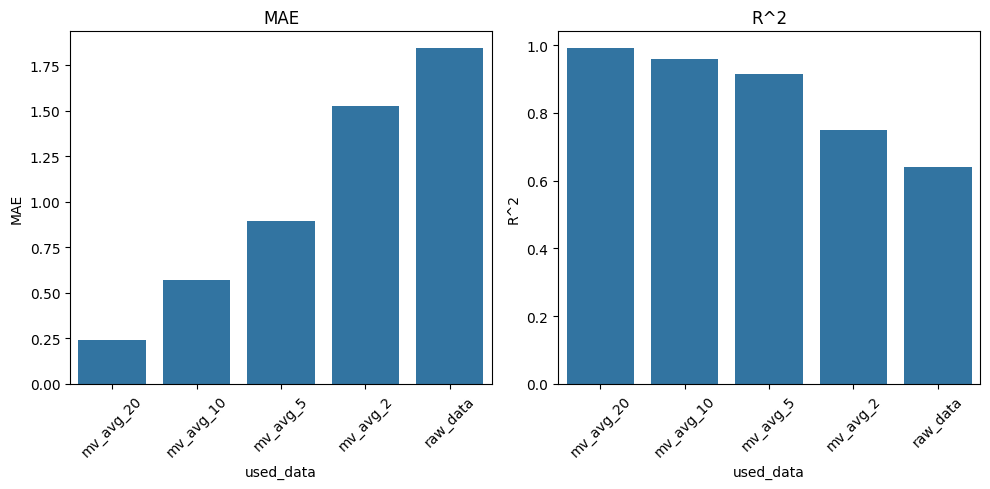

In [14]:
#MAEとR^2の推移を表示
MAE = [MAE_test_20, MAE_test_10, MAE_test_5, MAE_test_2, MAE_test]
R2 = [R2_test_20, R2_test_10, R2_test_5, R2_test_2, R2_test]
used_data = ["mv_avg_20", "mv_avg_10", "mv_avg_5", "mv_avg_2", "raw_data"]
Evaluations = pd.DataFrame({"MAE":MAE, "R^2":R2, "used_data":used_data})

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(Evaluations, x='used_data', y='MAE', errorbar=None)
plt.title('MAE')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(Evaluations, x='used_data', y='R^2', errorbar=None)
plt.xticks(rotation=45)
plt.title('R^2')
plt.tight_layout()

過去のデータ数を多く使用したデータほど予測精度が良い(MAEが小さくR^2が大きい)モデルが作成できた。

次に各センサのデータに"pl_vib_vec"を追加したデータセットでトライする。

In [15]:
path_processed = '../data/processed/processed_data.csv'
df = pd.read_csv(path_processed)

X = df.drop(["tool_wear"], axis=1)
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:23:03,745] A new study created in memory with name: no-name-f1f29234-7d80-4751-b4b5-ab75e58f12bf
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.966486:  14%|8     | 1/7 [00:00<00:01,  3.20it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  29%|#7    | 2/7 [00:00<00:01,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  43%|##5   | 3/7 [00:00<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  57%|###4  | 4/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950997:  71%|####2 | 5/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.950722:  86%|#####1| 6/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.950722:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.950722:   5%|5          | 1/20 [00:00<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.950722:  10%|#1         | 2/20 [00:00<00:06,  2.73it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.950722:  15%|#6         | 3/20 [00:01<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.892352:  25%|##7        | 5/20 [00:01<00:05,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

num_leaves, val_score: 1.854179:  40%|####4      | 8/20 [00:01<00:01,  6.46it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.854179:  45%|####9      | 9/20 [00:02<00:02,  4.91it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.854179:  50%|#####     | 10/20 [00:02<00:02,  4.10it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.854179:  55%|#####5    | 11/20 [00:02<00:02,  3.69it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.854179:  60%|######    | 12/20 [00:03<00:02,  3.39it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.854179:  75%|#######5  | 15/20 [00:03<00:00,  5.01it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.854179:  85%|########5 | 17/20 [00:04<00:00,  4.21it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.854179:  90%|######### | 18/20 [00:04<00:00,  4.57it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.854179:  95%|#########5| 19/20 [00:04<00:00,  4.00it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.838518:  60%|########4     | 6/10 [00:00<00:00, 36.44it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

[I 2025-11-03 09:23:11,202] Trial 33 finished with value: 1.847275909831854 and parameters: {'bagging_fraction': 0.961720014779417, 'bagging_freq': 1}. Best is trial 29 with value: 1.8385181992221573.
bagging, val_score: 1.838518: 100%|#############| 10/10 [00:00<00:00, 34.44it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.838518:  67%|6| 4/6 [00:00<00:00, 37.65it/[I 2025-11-03 09:23:11,397] Trial 40 finished with value: 1.8385181992221573 and parameters: {'feature_fraction': 0.82}. Best is trial 29 with value: 1.8385181992221573.
feature_fraction_stage2, val_score: 1.838518:  67%|6| 4/6 [00:00<00:00, 37.65it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.838518:  83%|8| 5/6 [00:00<00:00, 37.65it/[I 2025-11-03 09:23:11,448] Trial 42 finished with value: 1.8385181992221573 and parameters: {'feature_fraction': 0.9159999999999999}. Best is trial 29 with value: 1.8385181992221573.
feature_fraction_stage2, val_score: 1.838518: 100%|#| 6/6 [00:00<00:00, 37.93it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.838518:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 09:23:11,478] Trial 43 finished with value: 1.8385182011475887 and parameters: {'lambda_l1': 5.301862065542789e-06, 'lambda_l2': 6.697899998760525e-07}. Best is trial 29 with value: 1.8385181992221573.
regularization_factors, val_score: 1.838518:   5%| | 1/20 [00:00<00:00, 34.21it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.836065:  20%|2| 4/20 [00:00<00:00, 34.28it/[I 2025-11-03 09:23:11,596] Trial 47 finished with value: 1.837048272666294 and parameters: {'lambda_l1': 0.37335374397621224, 'lambda_l2': 0.05650112806664713}. Best is trial 46 with value: 1.836065118536173.
regularization_factors, val_score: 1.836065:  25%|2| 5/20 [00:00<00:00, 34.28it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.836065:  25%|2| 5/20 [00:00<00:00, 34.28it/[I 2025-11-03 09:23:11,625] Trial 48 finished with value: 1.8370449476359973 and parameters: {'lambda_l1': 0.39352114257520415, 'lambda_l2': 0.03488974375879459}. Best is trial 46 with value: 1.836065118536173.
regularization_factors, val_score: 1.836065:  30%|3| 6/20 [00:00<00:00, 34.28it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.836065:  40%|4| 8/20 [00:00<00:00, 33.95it/[I 2025-11-03 09:23:11,685] Trial 50 finished with value: 1.8370371193965673 and parameters: {'lambda_l1': 0.35946437973075734, 'lambda_l2': 0.044933392160316915}. Best is trial 46 with value: 1.836065118536173.
regularization_factors, val_score: 1.836065:  40%|4| 8/20 [00:00<00:00, 33.95it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.836035:  60%|6| 12/20 [00:00<00:00, 34.00it[I 2025-11-03 09:23:11,802] Trial 54 finished with value: 1.8360353185967262 and parameters: {'lambda_l1': 0.11213353164927899, 'lambda_l2': 0.024289787028004373}. Best is trial 54 with value: 1.8360353185967262.
regularization_factors, val_score: 1.836035:  60%|6| 12/20 [00:00<00:00, 34.00it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.835933:  60%|6| 12/20 [00:00<00:00, 34.00it[I 2025-11-03 09:23:11,831] Trial 55 finished with value: 1.8359327159118313 and parameters: {'lambda_l1': 0.024762132883660935, 'lambda_l2': 0.021629780107504715}. Best is trial 55 with value: 1.8359327159118313.
regularization_factors, val_score: 1.835933:  65%|6| 13/20 [00:00<00:00, 34.00it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.835916:  70%|7| 14/20 [00:00<00:00, 34.00it[I 2025-11-03 09:23:11,890] Trial 57 finished with value: 1.835916345835564 and parameters: {'lambda_l1': 0.0035164572381145864, 'lambda_l2': 0.001466823451073816}. Best is trial 57 with value: 1.835916345835564.
regularization_factors, val_score: 1.835916:  75%|7| 15/20 [00:00<00:00, 34.00it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.835915:  90%|9| 18/20 [00:00<00:00, 34.15it[I 2025-11-03 09:23:12,007] Trial 61 finished with value: 1.835915287584838 and parameters: {'lambda_l1': 0.0017372559173729901, 'lambda_l2': 0.00044777485151330086}. Best is trial 61 with value: 1.835915287584838.
regularization_factors, val_score: 1.835915:  95%|9| 19/20 [00:00<00:00, 34.15it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.835915: 100%|#| 20/20 [00:00<00:00, 34.02it[I 2025-11-03 09:23:12,037] Trial 62 finished with value: 1.8359153422620866 and parameters: {'lambda_l1': 0.0017491648835064682, 'lambda_l2': 0.000564874253817999}. Best is trial 61 with value: 1.835915287584838.
regularization_factors, val_score: 1.835915: 100%|#| 20/20 [00:00<00:00, 34.02it
min_child_samples, val_score: 1.835915:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.835915:  40%|##   | 2/5 [00:00<00:00, 33.94it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.834831: 100%|#####| 5/5 [00:00<00:00, 34.91it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 6
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 0.8999999999999999, 'bagging_freq': 7, 'bagging_fraction': 0.40122864567316996, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.0017372559173729901, 'lambda_l2': 0.00044777485151330086, 'min_

In [17]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_proc  =mean_absolute_error(y_train, train_predict)
MAE_test_proc  =mean_absolute_error(y_test, test_predict)
R2_train_proc = r2_score(y_train, train_predict)
R2_test_proc = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_proc, MAE_test_proc))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_proc, R2_test_proc))

MAE train:1.812, MAE test:1.835
R^2 train:0.688, R^2 test:0.628


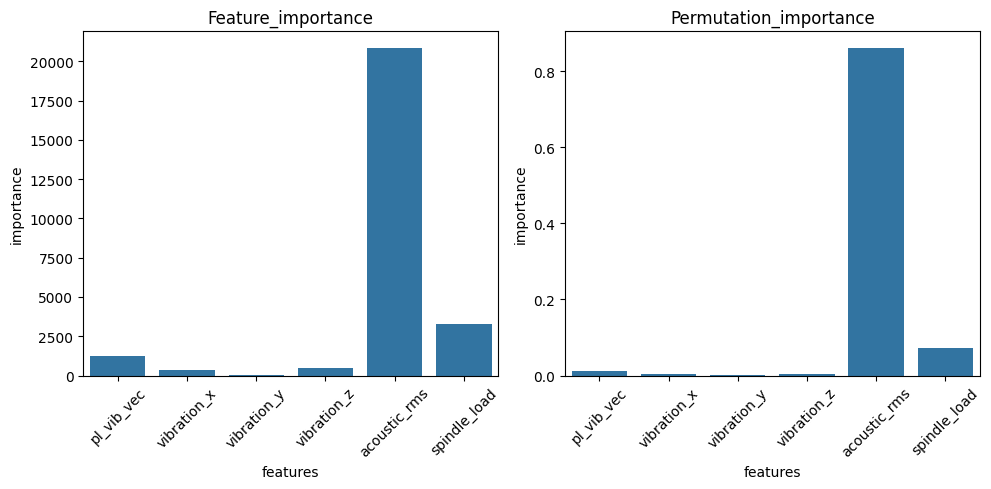

In [18]:
feature_importance_proc = pd.DataFrame(zip(X.columns, adjusted_model.feature_importance(importance_type='gain')), columns=['features', 'importance'])

regressor_model = lgb.LGBMRegressor()
regressor_model._Booster = adjusted_model
regressor_model._n_features = X_test.shape[1]
regressor_model.fitted_ = True
result_proc = permutation_importance(regressor_model, X_test, y_test, n_repeats=10, random_state=42)
purmutation_importance_proc = pd.DataFrame(zip(X.columns, result_proc['importances'].mean(axis=1)), columns=['features', 'importance'])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(feature_importance_proc, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Feature_importance')
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(purmutation_importance_proc, x='features', y='importance', errorbar=None)
plt.xticks(rotation=45)
plt.title('Permutation_importance')
plt.tight_layout()

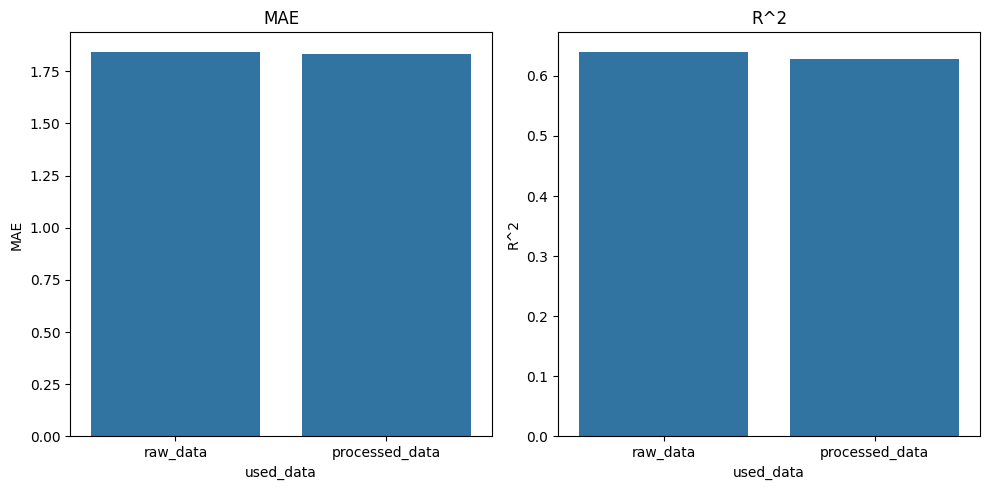

In [19]:
#MAEとR^2の推移を表示
df_con = pd.DataFrame({"MAE":[MAE_test, MAE_test_proc], "R^2":[R2_test, R2_test_proc], "used_data": ["raw_data", "processed_data"]})

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(df_con, x='used_data', y='MAE', errorbar=None)
plt.title('MAE')
plt.tight_layout()

plt.subplot(1,2,2)
sns.barplot(df_con, x='used_data', y='R^2', errorbar=None)
plt.title('R^2')
plt.tight_layout()

生データと"pl_vib_vec"を追加したデータセットでMAEもR^2もほぼ変わらなかった(MAE変化率 -0.5%)。特徴量の重要度評価からも、追加した特徴量はあまりモデルの予測精度には寄与しなかったことが分かる。

複数回の加工のデータの移動平均を使用することでモデルの予測精度を高めることができたが、１回の加工単位ではセンサー値のブレが大きく、特徴量化が難しいと考える。

続いて、必要なセンサを確認するため、重要度評価が低いセンサのデータを削減してモデルを再度作成する。使用するデータセットは、生データと作成した中で最も予測精度の良いモデルを作成できた、20回の加工データの移動平均をとったデータセット。

In [20]:
#生データから重要度評価が最も低い特徴量を削除して再評価
path = '../data/raw/Milling_Tool_Dataset.csv'
df = pd.read_csv(path)

X = df[["vibration_x", "vibration_y", "acoustic_rms", "spindle_load"]]
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:24:52,664] A new study created in memory with name: no-name-9bd75b47-1c9f-44ab-a74c-0da86a7ac745
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  14%|8     | 1/7 [00:00<00:01,  3.18it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  29%|#7    | 2/7 [00:00<00:01,  3.29it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  43%|##5   | 3/7 [00:00<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  57%|###4  | 4/7 [00:01<00:00,  3.06it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  71%|####2 | 5/7 [00:01<00:00,  3.15it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.990633:  86%|#####1| 6/7 [00:01<00:00,  3.20it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.946227:   5%|5          | 1/20 [00:00<00:03,  5.71it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.946227:  10%|#1         | 2/20 [00:00<00:05,  3.54it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.946227:  15%|#6         | 3/20 [00:00<00:05,  3.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868554:  30%|###3       | 6/20 [00:01<00:02,  5.72it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

num_leaves, val_score: 1.868554:  35%|###8       | 7/20 [00:01<00:02,  4.42it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868554:  40%|####4      | 8/20 [00:01<00:02,  4.85it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

num_leaves, val_score: 1.868554:  45%|####9      | 9/20 [00:02<00:02,  3.99it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868554:  50%|#####     | 10/20 [00:02<00:02,  3.57it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.868554:  55%|#####5    | 11/20 [00:02<00:02,  3.33it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.867645:  65%|######5   | 13/20 [00:03<00:02,  3.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.867645:  70%|#######   | 14/20 [00:03<00:01,  3.84it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.867645:  80%|########  | 16/20 [00:03<00:00,  5.49it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

num_leaves, val_score: 1.867645:  85%|########5 | 17/20 [00:04<00:00,  4.55it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.867645:  90%|######### | 18/20 [00:04<00:00,  3.96it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.867645:  95%|#########5| 19/20 [00:04<00:00,  3.61it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.867645: 100%|##########| 20/20 [00:05<00:00,  3.88it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


bagging, val_score: 1.865363:  40%|#####6        | 4/10 [00:00<00:00, 25.06it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

bagging, val_score: 1.860277:  50%|#######       | 5/10 [00:00<00:00, 25.06it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.833659: 100%|#############| 10/10 [00:00<00:00, 25.27it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

feature_fraction_stage2, val_score: 1.833659:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.833659: 100%|#| 3/3 [00:00<00:00, 24.83it/[I 2025-11-03 09:25:00,516] Trial 39 finished with value: 1.833659478467225 and parameters: {'feature_fraction': 0.92}. Best is trial 32 with value: 1.833659478467225.
feature_fraction_stage2, val_score: 1.833659: 100%|#| 3/3 [00:00<00:00, 24.73it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:   5%| | 1/20 [00:00<00:01, 13.37it/[I 2025-11-03 09:25:00,592] Trial 41 finished with value: 1.8409557960508427 and parameters: {'lambda_l1': 0.10915631072086791, 'lambda_l2': 0.00019306197207225896}. Best is trial 32 with value: 1.833659478467225.
regularization_factors, val_score: 1.833659:  10%|1| 2/20 [00:00<00:00, 26.57it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training fro

regularization_factors, val_score: 1.833659:  15%|1| 3/20 [00:00<00:00, 26.48it/[I 2025-11-03 09:25:00,630] Trial 42 finished with value: 1.8336594779722615 and parameters: {'lambda_l1': 2.7035814494091912e-06, 'lambda_l2': 1.4868340360787644e-08}. Best is trial 42 with value: 1.8336594779722615.
regularization_factors, val_score: 1.833659:  15%|1| 3/20 [00:00<00:00, 26.48it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  20%|2| 4/20 [00:00<00:00, 26.48it/[I 2025-11-03 09:25:00,712] Trial 44 finished with value: 1.8336594784587867 and parameters: {'lambda_l1': 2.8755732219468033e-08, 'lambda_l2': 1.6483232354680965e-08}. Best is trial 42 with value: 1.8336594779722615.
regularization_factors, val_score: 1.833659:  25%|2| 5/20 [00:00<00:00, 26.48it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  30%|3| 6/20 [00:00<00:00, 24.54it/[I 2025-11-03 09:25:00,805] Trial 46 finished with value: 1.8336594784514695 and parameters: {'lambda_l1': 6.81831303173787e-08, 'lambda_l2': 1.1607767259130585e-08}. Best is trial 42 with value: 1.8336594779722615.
regularization_factors, val_score: 1.833659:  35%|3| 7/20 [00:00<00:00, 24.54it/

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  35%|3| 7/20 [00:00<00:00, 24.54it/[I 2025-11-03 09:25:00,847] Trial 47 finished with value: 1.8336594784517943 and parameters: {'lambda_l1': 5.468185628838555e-08, 'lambda_l2': 1.3673307591665298e-08}. Best is trial 42 with value: 1.8336594779722615.
regularization_factors, val_score: 1.833659:  40%|4| 8/20 [00:00<00:00, 24.54it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  45%|4| 9/20 [00:00<00:00, 23.95it/[I 2025-11-03 09:25:00,928] Trial 49 finished with value: 1.8336594784440046 and parameters: {'lambda_l1': 3.179049674551515e-07, 'lambda_l2': 1.0551930039749266e-08}. Best is trial 42 with value: 1.8336594779722615.
regularization_factors, val_score: 1.833659:  50%|5| 10/20 [00:00<00:00, 23.95it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  60%|6| 12/20 [00:00<00:00, 24.28it[I 2025-11-03 09:25:01,009] Trial 51 finished with value: 1.8336594780257829 and parameters: {'lambda_l1': 2.2200103167433765e-06, 'lambda_l2': 1.1933058547283117e-08}. Best is trial 42 with value: 1.8336594779722615.
regularization_factors, val_score: 1.833659:  60%|6| 12/20 [00:00<00:00, 24.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  65%|6| 13/20 [00:00<00:00, 24.28it[I 2025-11-03 09:25:01,090] Trial 53 finished with value: 1.8336594757074105 and parameters: {'lambda_l1': 1.2574755520066497e-05, 'lambda_l2': 4.874130918935868e-07}. Best is trial 53 with value: 1.8336594757074105.
regularization_factors, val_score: 1.833659:  70%|7| 14/20 [00:00<00:00, 24.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  75%|7| 15/20 [00:00<00:00, 24.34it[I 2025-11-03 09:25:01,131] Trial 54 finished with value: 1.8336594756043068 and parameters: {'lambda_l1': 1.333482597852736e-05, 'lambda_l2': 1.8192872385641328e-06}. Best is trial 54 with value: 1.8336594756043068.
regularization_factors, val_score: 1.833659:  75%|7| 15/20 [00:00<00:00, 24.34it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  80%|8| 16/20 [00:00<00:00, 24.34it[I 2025-11-03 09:25:01,212] Trial 56 finished with value: 1.8336594743050152 and parameters: {'lambda_l1': 1.7820249596015153e-05, 'lambda_l2': 2.3481835310703502e-06}. Best is trial 55 with value: 1.8336594738175698.
regularization_factors, val_score: 1.833659:  85%|8| 17/20 [00:00<00:00, 24.34it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  90%|9| 18/20 [00:00<00:00, 24.47it[I 2025-11-03 09:25:01,253] Trial 57 finished with value: 1.8336594659884065 and parameters: {'lambda_l1': 5.426635244202524e-05, 'lambda_l2': 2.1036244563240382e-06}. Best is trial 57 with value: 1.8336594659884065.
regularization_factors, val_score: 1.833659:  90%|9| 18/20 [00:00<00:00, 24.47it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.833659:  95%|9| 19/20 [00:00<00:00, 24.47it[I 2025-11-03 09:25:01,333] Trial 59 finished with value: 1.8336594458861528 and parameters: {'lambda_l1': 0.00014091644806998535, 'lambda_l2': 2.1648071400267214e-06}. Best is trial 59 with value: 1.8336594458861528.
regularization_factors, val_score: 1.833659: 100%|#| 20/20 [00:00<00:00, 24.49it


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.833659:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.833659:  40%|##   | 2/5 [00:00<00:00, 24.66it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.833659:  60%|###  | 3/5 [00:00<00:00, 24.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.833659:  80%|#### | 4/5 [00:00<00:00, 24.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 4
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.832983: 100%|#####| 5/5 [00:00<00:00, 24.65it/s]

Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 3, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 5, 'bagging_fraction': 0.8390796573250077, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 0.00014091644806998535, 'lambda_l2': 2.1648071400267214e-06, 'min_child_samples': 25}


In [21]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_del_z  =mean_absolute_error(y_train, train_predict)
MAE_test_del_z  =mean_absolute_error(y_test, test_predict)
R2_train_del_z = r2_score(y_train, train_predict)
R2_test_del_z = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_del_z, MAE_test_del_z))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_del_z, R2_test_del_z))

MAE train:1.735, MAE test:1.833
R^2 train:0.712, R^2 test:0.637


In [22]:
#MAEが元データの5%下がるまで特徴量の削除を続行
path = '../data/raw/Milling_Tool_Dataset.csv'
df = pd.read_csv(path)

X = df[["vibration_x", "acoustic_rms", "spindle_load"]]
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:25:07,382] A new study created in memory with name: no-name-429d3920-fe53-4611-ba17-e25c52c2ea57
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  14%|8     | 1/7 [00:00<00:01,  3.14it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  29%|#7    | 2/7 [00:00<00:01,  3.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  43%|##5   | 3/7 [00:00<00:01,  3.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  57%|###4  | 4/7 [00:01<00:00,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  71%|####2 | 5/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.963070:  86%|#####1| 6/7 [00:01<00:00,  3.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.963070:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.963070:   5%|5          | 1/20 [00:00<00:06,  2.72it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.963070:  10%|#1         | 2/20 [00:00<00:06,  2.74it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.963070:  15%|#6         | 3/20 [00:01<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.963070:  20%|##2        | 4/20 [00:01<00:05,  2.74it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

num_leaves, val_score: 1.884461:  30%|###3       | 6/20 [00:01<00:05,  2.74it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.884461:  40%|####4      | 8/20 [00:02<00:02,  4.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.862697:  50%|#####     | 10/20 [00:02<00:01,  6.07it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

num_leaves, val_score: 1.862697:  55%|#####5    | 11/20 [00:02<00:01,  4.72it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.862697:  60%|######    | 12/20 [00:03<00:02,  3.99it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.862697:  65%|######5   | 13/20 [00:03<00:01,  3.57it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.862697:  75%|#######5  | 15/20 [00:03<00:01,  3.30it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.862697:  80%|########  | 16/20 [00:03<00:01,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


num_leaves, val_score: 1.862697:  85%|########5 | 17/20 [00:04<00:00,  4.58it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.862697:  95%|#########5| 19/20 [00:04<00:00,  4.03it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.862697: 100%|##########| 20/20 [00:05<00:00,  3.92it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 1.857730:  20%|##8           | 2/10 [00:00<00:00, 19.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

bagging, val_score: 1.857730:  40%|#####6        | 4/10 [00:00<00:00, 19.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.854095:  70%|#########7    | 7/10 [00:00<00:00, 20.38it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from s

bagging, val_score: 1.854095:  80%|###########2  | 8/10 [00:00<00:00, 20.14it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


bagging, val_score: 1.852244: 100%|#############| 10/10 [00:00<00:00, 19.90it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.852244:   0%|       | 0/3 [00:00<?, ?it/s][I 2025-11-03 09:25:15,174] Trial 37 finished with value: 1.8522440820897312 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 36 with value: 1.8522440820897312.
feature_fraction_stage2, val_score: 1.852244:  33%|3| 1/3 [00:00<00:00, 19.20it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.852244:  67%|6| 2/3 [00:00<00:00, 19.45it/[I 2025-11-03 09:25:15,225] Trial 38 finished with value: 1.8522440820897312 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 36 with value: 1.8522440820897312.
feature_fraction_stage2, val_score: 1.852244:  67%|6| 2/3 [00:00<00:00, 19.45it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.852244:  67%|6| 2/3 [00:00<00:00, 19.45it/[I 2025-11-03 09:25:15,277] Trial 39 finished with value: 1.8522440820897312 and parameters: {'feature_fraction': 0.92}. Best is trial 36 with value: 1.8522440820897312.
feature_fraction_stage2, val_score: 1.852244: 100%|#| 3/3 [00:00<00:00, 19.36it/
regularization_factors, val_score: 1.852244:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.852229:  10%|1| 2/20 [00:00<00:00, 18.97it/[I 2025-11-03 09:25:15,383] Trial 41 finished with value: 1.8537436801534444 and parameters: {'lambda_l1': 0.0005672808433843164, 'lambda_l2': 0.12555398701684073}. Best is trial 40 with value: 1.8522288941940777.
regularization_factors, val_score: 1.852229:  10%|1| 2/20 [00:00<00:00, 18.97it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.851426:  10%|1| 2/20 [00:00<00:00, 18.97it/[I 2025-11-03 09:25:15,435] Trial 42 finished with value: 1.851425772222514 and parameters: {'lambda_l1': 6.229716988068151, 'lambda_l2': 6.549298054194288e-07}. Best is trial 42 with value: 1.851425772222514.
regularization_factors, val_score: 1.851426:  15%|1| 3/20 [00:00<00:00, 18.97it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.849741:  20%|2| 4/20 [00:00<00:00, 19.13it/[I 2025-11-03 09:25:15,487] Trial 43 finished with value: 1.84974122290478 and parameters: {'lambda_l1': 6.775436326523778, 'lambda_l2': 3.458513892735836e-08}. Best is trial 43 with value: 1.84974122290478.
regularization_factors, val_score: 1.849741:  20%|2| 4/20 [00:00<00:00, 19.13it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846354:  30%|3| 6/20 [00:00<00:00, 19.05it/[I 2025-11-03 09:25:15,593] Trial 45 finished with value: 1.846354298533588 and parameters: {'lambda_l1': 7.145595650194299, 'lambda_l2': 1.097050824428463e-08}. Best is trial 45 with value: 1.846354298533588.
regularization_factors, val_score: 1.846354:  30%|3| 6/20 [00:00<00:00, 19.05it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  30%|3| 6/20 [00:00<00:00, 19.05it/[I 2025-11-03 09:25:15,645] Trial 46 finished with value: 1.8463462441653253 and parameters: {'lambda_l1': 7.157423562999793, 'lambda_l2': 2.310229624857347e-08}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  35%|3| 7/20 [00:00<00:00, 19.05it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  40%|4| 8/20 [00:00<00:00, 19.04it/[I 2025-11-03 09:25:15,698] Trial 47 finished with value: 1.8500297259690857 and parameters: {'lambda_l1': 9.861321233574532, 'lambda_l2': 1.0220066698421493e-08}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  40%|4| 8/20 [00:00<00:00, 19.04it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  50%|5| 10/20 [00:00<00:00, 19.07it[I 2025-11-03 09:25:15,802] Trial 49 finished with value: 1.8498171426763135 and parameters: {'lambda_l1': 4.877995298786541, 'lambda_l2': 1.4004996907789622e-08}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  50%|5| 10/20 [00:00<00:00, 19.07it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  50%|5| 10/20 [00:00<00:00, 19.07it[I 2025-11-03 09:25:15,855] Trial 50 finished with value: 1.8479803868068643 and parameters: {'lambda_l1': 3.5732111912147153, 'lambda_l2': 2.5807013533053945e-08}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  55%|5| 11/20 [00:00<00:00, 19.07it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  60%|6| 12/20 [00:00<00:00, 19.11it[I 2025-11-03 09:25:15,907] Trial 51 finished with value: 1.8563056332595773 and parameters: {'lambda_l1': 6.11716846203337, 'lambda_l2': 2.7045666632215924e-08}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  60%|6| 12/20 [00:00<00:00, 19.11it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  70%|7| 14/20 [00:00<00:00, 19.18it[I 2025-11-03 09:25:16,010] Trial 53 finished with value: 1.8484960502986978 and parameters: {'lambda_l1': 0.1721781779758044, 'lambda_l2': 4.5149381940828493e-07}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  70%|7| 14/20 [00:00<00:00, 19.18it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  70%|7| 14/20 [00:00<00:00, 19.18it[I 2025-11-03 09:25:16,062] Trial 54 finished with value: 1.8521956965522302 and parameters: {'lambda_l1': 0.06543749946660805, 'lambda_l2': 1.6527324123205007e-06}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  75%|7| 15/20 [00:00<00:00, 19.18it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  80%|8| 16/20 [00:00<00:00, 19.16it[I 2025-11-03 09:25:16,115] Trial 55 finished with value: 1.852171443788562 and parameters: {'lambda_l1': 0.09823929598390783, 'lambda_l2': 4.4195478623525377e-07}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  80%|8| 16/20 [00:00<00:00, 19.16it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  90%|9| 18/20 [00:00<00:00, 19.10it[I 2025-11-03 09:25:16,220] Trial 57 finished with value: 1.8521766082072213 and parameters: {'lambda_l1': 0.09124665741609311, 'lambda_l2': 1.194487815463937e-05}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  90%|9| 18/20 [00:00<00:00, 19.10it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346:  90%|9| 18/20 [00:00<00:00, 19.10it[I 2025-11-03 09:25:16,272] Trial 58 finished with value: 1.8537490452171108 and parameters: {'lambda_l1': 0.29060098093449205, 'lambda_l2': 3.196393755724241e-07}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346:  95%|9| 19/20 [00:00<00:00, 19.10it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.846346: 100%|#| 20/20 [00:01<00:00, 19.10it[I 2025-11-03 09:25:16,325] Trial 59 finished with value: 1.8522440820144224 and parameters: {'lambda_l1': 1.33472401518075e-08, 'lambda_l2': 1.7056452747670575e-07}. Best is trial 46 with value: 1.8463462441653253.
regularization_factors, val_score: 1.846346: 100%|#| 20/20 [00:01<00:00, 19.09it
min_child_samples, val_score: 1.846346:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.846346:  40%|##   | 2/5 [00:00<00:00, 19.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.846346:  60%|###  | 3/5 [00:00<00:00, 19.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.846346:  80%|#### | 4/5 [00:00<00:00, 19.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 3
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.846346: 100%|#####| 5/5 [00:00<00:00, 19.37it/s]

Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 4, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 5, 'bagging_fraction': 0.8064756661909828, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 7.157423562999793, 'lambda_l2': 2.310229624857347e-08, 'min_child_samples': 20}


In [23]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_del_yz  =mean_absolute_error(y_train, train_predict)
MAE_test_del_yz  =mean_absolute_error(y_test, test_predict)
R2_train_del_yz = r2_score(y_train, train_predict)
R2_test_del_yz = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_del_yz, MAE_test_del_yz))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_del_yz, R2_test_del_yz))

MAE train:1.719, MAE test:1.846
R^2 train:0.718, R^2 test:0.634


In [24]:
path = '../data/raw/Milling_Tool_Dataset.csv'
df = pd.read_csv(path)

X = df[["acoustic_rms", "spindle_load"]]
y = df["tool_wear"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:25:20,588] A new study created in memory with name: no-name-ca571599-8d28-497b-8fc3-0ced07d706ee
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  14%|8     | 1/7 [00:00<00:01,  3.17it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  29%|#7    | 2/7 [00:00<00:01,  3.23it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  43%|##5   | 3/7 [00:00<00:01,  3.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  57%|###4  | 4/7 [00:01<00:00,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  71%|####2 | 5/7 [00:01<00:00,  3.25it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 1.959869:  86%|#####1| 6/7 [00:01<00:00,  3.26it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.959869:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.959869:   5%|5          | 1/20 [00:00<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.959869:  10%|#1         | 2/20 [00:00<00:06,  2.75it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.959869:  15%|#6         | 3/20 [00:01<00:06,  2.76it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  30%|###3       | 6/20 [00:01<00:02,  5.03it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train se

num_leaves, val_score: 1.888318:  40%|####4      | 8/20 [00:01<00:01,  6.75it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

num_leaves, val_score: 1.888318:  45%|####9      | 9/20 [00:02<00:02,  5.06it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 1.888318:  50%|#####     | 10/20 [00:02<00:02,  4.19it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  60%|######    | 12/20 [00:02<00:02,  3.68it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  65%|######5   | 13/20 [00:03<00:01,  4.15it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  75%|#######5  | 15/20 [00:03<00:01,  3.71it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 1.888318:  80%|########  | 16/20 [00:03<00:00,  4.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 1.888318:  90%|######### | 18/20 [00:04<00:00,  3.95it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

num_leaves, val_score: 1.888318:  95%|#########5| 19/20 [00:04<00:00,  4.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

bagging, val_score: 1.874558:  70%|#########7    | 7/10 [00:00<00:00, 35.52it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

bagging, val_score: 1.874558: 100%|#############| 10/10 [00:00<00:00, 34.30it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction_stage2, val_score: 1.874558:  67%|6| 2/3 [00:00<00:00, 24.20it/[I 2025-11-03 09:25:28,145] Trial 39 finished with value: 1.874558133590551 and parameters: {'feature_fraction': 0.92}. Best is trial 30 with value: 1.874558133590551.
feature_fraction_stage2, val_score: 1.874558: 100%|#| 3/3 [00:00<00:00, 36.06it/


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.874249:   0%|       | 0/20 [00:00<?, ?it/s][I 2025-11-03 09:25:28,174] Trial 40 finished with value: 1.8742488208776593 and parameters: {'lambda_l1': 1.1229660741781571e-06, 'lambda_l2': 0.0762025761571628}. Best is trial 40 with value: 1.8742488208776593.
regularization_factors, val_score: 1.874249:   5%| | 1/20 [00:00<00:00, 34.68it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873690:  20%|2| 4/20 [00:00<00:00, 34.73it/[I 2025-11-03 09:25:28,261] Trial 43 finished with value: 1.873690273173298 and parameters: {'lambda_l1': 2.946835679268882e-07, 'lambda_l2': 0.26109435917708884}. Best is trial 43 with value: 1.873690273173298.
regularization_factors, val_score: 1.873690:  20%|2| 4/20 [00:00<00:00, 34.73it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.873688:  25%|2| 5/20 [00:00<00:00, 34.73it/[I 2025-11-03 09:25:28,321] Trial 45 finished with value: 1.8736879523450145 and parameters: {'lambda_l1': 2.30950719808002e-07, 'lambda_l2': 0.2049933569850269}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  30%|3| 6/20 [00:00<00:00, 34.73it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  40%|4| 8/20 [00:00<00:00, 33.98it/[I 2025-11-03 09:25:28,381] Trial 47 finished with value: 1.873752404426984 and parameters: {'lambda_l1': 1.1031448090452164e-07, 'lambda_l2': 0.3676635755389015}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  40%|4| 8/20 [00:00<00:00, 33.98it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  50%|5| 10/20 [00:00<00:00, 33.98it[I 2025-11-03 09:25:28,470] Trial 50 finished with value: 1.8781780426162755 and parameters: {'lambda_l1': 7.969138333147079, 'lambda_l2': 2.3797434377169674e-06}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  55%|5| 11/20 [00:00<00:00, 33.98it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.873688:  60%|6| 12/20 [00:00<00:00, 33.72it[I 2025-11-03 09:25:28,534] Trial 52 finished with value: 1.8738550559545597 and parameters: {'lambda_l1': 9.157172606576182e-08, 'lambda_l2': 0.16016645517837916}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  65%|6| 13/20 [00:00<00:00, 33.72it

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  70%|7| 14/20 [00:00<00:00, 33.72it[I 2025-11-03 09:25:28,593] Trial 54 finished with value: 1.8745589806517047 and parameters: {'lambda_l1': 1.8593797303153832e-08, 'lambda_l2': 0.005197485511815292}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  75%|7| 15/20 [00:00<00:00, 33.72it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


regularization_factors, val_score: 1.873688:  85%|8| 17/20 [00:00<00:00, 33.28it[I 2025-11-03 09:25:28,683] Trial 57 finished with value: 1.8745620605754487 and parameters: {'lambda_l1': 3.307068764980898e-06, 'lambda_l2': 0.024069103853265612}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688:  90%|9| 18/20 [00:00<00:00, 33.28it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from s

regularization_factors, val_score: 1.873688: 100%|#| 20/20 [00:00<00:00, 33.25it[I 2025-11-03 09:25:28,743] Trial 59 finished with value: 1.8745610700886506 and parameters: {'lambda_l1': 8.139256591547592e-07, 'lambda_l2': 0.018001409925475477}. Best is trial 45 with value: 1.8736879523450145.
regularization_factors, val_score: 1.873688: 100%|#| 20/20 [00:00<00:00, 33.45it


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.873688:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.871253:  40%|##   | 2/5 [00:00<00:00, 33.91it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


min_child_samples, val_score: 1.871253: 100%|#####| 5/5 [00:00<00:00, 34.02it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
Best params: {'objective': 'regression', 'metric': 'l1', 'num_leaves': 2, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_freq': 5, 'bagging_fraction': 0.888267196787217, 'random_state': 0, 'feature_pre_filter': False, 'lambda_l1': 2.30950719808002e-07, 'lambda_l2': 0.2049933569850269, 'min_child_samples': 100}


In [25]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_del_vib  =mean_absolute_error(y_train, train_predict)
MAE_test_del_vib  =mean_absolute_error(y_test, test_predict)
R2_train_del_vib = r2_score(y_train, train_predict)
R2_test_del_vib = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_del_vib, MAE_test_del_vib))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_del_vib, R2_test_del_vib))

MAE train:1.878, MAE test:1.871
R^2 train:0.670, R^2 test:0.630


MAE: 2.105
R²: 0.587
回帰式: tool_wear = 40.3962 * acoustic_rms + -17.1735


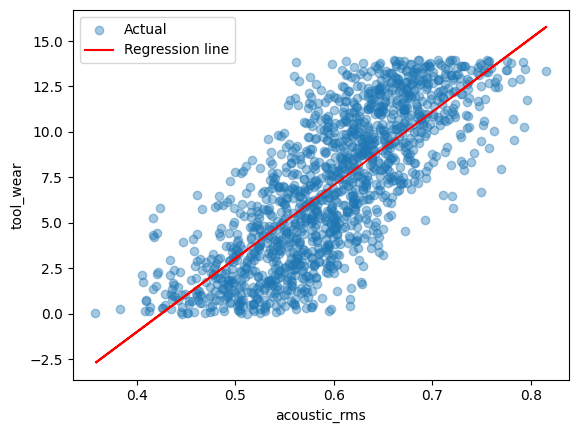

In [26]:
from sklearn.linear_model import LinearRegression
X = df[['acoustic_rms']]
y = df['tool_wear']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"MAE: {mean_absolute_error(y, y_pred):.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"回帰式: tool_wear = {model.coef_[0]:.4f} * acoustic_rms + {model.intercept_:.4f}")

plt.scatter(X, y, alpha=0.4, label='Actual')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.xlabel('acoustic_rms')
plt.ylabel('tool_wear')
plt.legend()
plt.show()

生データから振動データ(vibration_x, vibration_y, vibration_z)を削除しても、予測精度はほとんど変わらなかった(MSEの変化率 +1.5%)。

さらに"spindle_load"を削除し、"acoustic_rms"のみを使用して単回帰分析を行った。この分析の評価は R^2=0.587, MAE=2.105であり、"acoustic_rms"のみでもある程度"tool_wear"を説明できている。

以上から、音響データ(acoustic_rms)が振動データやスピンドル負荷(spindle_load)データを内包している可能性が考えられる。

続いて、20回分の加工データの移動平均を使用したデータセットでも、振動データと"spindle_load"を除去してモデルを作成し、MAEの変化を確認する。

In [27]:
path_avg = '../data/processed/mv_avg_20.csv'
df = pd.read_csv(path_avg)

X = df[["mv_avg_ar", "mv_avg_sl"]]
y = df["tool_wear"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

trains = lgb.Dataset(X_train, y_train)
tests = lgb.Dataset(X_test, y_test)

model = lgb_tuner.LightGBMTuner(
    params, trains,valid_sets=[tests],
    num_boost_round=num_round,)

model.run()

best_params = model.best_params
print("Best params:", best_params)

adjusted_model = model.get_best_booster()

[I 2025-11-03 09:25:38,796] A new study created in memory with name: no-name-dad71f03-1a25-4043-986c-0ccadef44978
feature_fraction, val_score: inf:   0%|                   | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  14%|8     | 1/7 [00:00<00:01,  3.22it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  29%|#7    | 2/7 [00:00<00:01,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  43%|##5   | 3/7 [00:00<00:01,  3.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  57%|###4  | 4/7 [00:01<00:00,  3.32it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  71%|####2 | 5/7 [00:01<00:00,  3.30it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


feature_fraction, val_score: 0.403093:  86%|#####1| 6/7 [00:01<00:00,  3.28it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.403093:   0%|                   | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.402789:   5%|5          | 1/20 [00:00<00:06,  2.83it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  10%|#1         | 2/20 [00:00<00:06,  2.85it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.402789:  15%|#6         | 3/20 [00:01<00:05,  2.88it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

num_leaves, val_score: 0.402789:  20%|##2        | 4/20 [00:01<00:05,  2.88it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.397511:  25%|##7        | 5/20 [00:01<00:05,  2.93it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.397511:  35%|###8       | 7/20 [00:02<00:03,  3.96it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.397511:  40%|####4      | 8/20 [00:02<00:03,  3.96it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.397511:  45%|####9      | 9/20 [00:02<00:02,  4.61it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.397511:  50%|#####     | 10/20 [00:02<00:02,  4.06it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.397511:  55%|#####5    | 11/20 [00:03<00:02,  3.64it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572


num_leaves, val_score: 0.397511:  60%|######    | 12/20 [00:03<00:02,  3.38it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.397511:  65%|######5   | 13/20 [00:03<00:02,  3.24it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.397511:  70%|#######   | 14/20 [00:04<00:01,  3.09it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.397511:  75%|#######5  | 15/20 [00:04<00:01,  3.27it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.397511:  80%|########  | 16/20 [00:04<00:01,  3.21it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

num_leaves, val_score: 0.397511:  90%|######### | 18/20 [00:05<00:00,  3.09it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

num_leaves, val_score: 0.397511:  95%|#########5| 19/20 [00:05<00:00,  3.66it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

num_leaves, val_score: 0.397511: 100%|##########| 20/20 [00:05<00:00,  3.39it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


bagging, val_score: 0.397511:   0%|                      | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

bagging, val_score: 0.397511:  10%|#4            | 1/10 [00:00<00:02,  3.30it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  20%|##8           | 2/10 [00:00<00:01,  4.80it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  30%|####2         | 3/10 [00:00<00:01,  3.71it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  40%|#####6        | 4/10 [00:00<00:01,  4.43it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  50%|#######       | 5/10 [00:01<00:01,  4.41it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  60%|########4     | 6/10 [00:01<00:00,  4.50it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  70%|#########7    | 7/10 [00:01<00:00,  3.78it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  80%|###########2  | 8/10 [00:02<00:00,  3.73it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511:  90%|############6 | 9/10 [00:02<00:00,  4.02it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

bagging, val_score: 0.397511: 100%|#############| 10/10 [00:02<00:00,  3.97it/s]


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.397511:   0%|       | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

feature_fraction_stage2, val_score: 0.397511:  33%|3| 1/3 [00:00<00:00,  2.76it/[I 2025-11-03 09:25:49,697] Trial 37 finished with value: 0.39751067293640163 and parameters: {'feature_fraction': 0.9520000000000001}. Best is trial 11 with value: 0.39751067293640163.
feature_fraction_stage2, val_score: 0.397511:  33%|3| 1/3 [00:00<00:00,  2.76it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

feature_fraction_stage2, val_score: 0.397511:  67%|6| 2/3 [00:00<00:00,  2.78it/[I 2025-11-03 09:25:50,053] Trial 38 finished with value: 0.39751067293640163 and parameters: {'feature_fraction': 0.9840000000000001}. Best is trial 11 with value: 0.39751067293640163.
feature_fraction_stage2, val_score: 0.397511:  67%|6| 2/3 [00:00<00:00,  2.78it/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

feature_fraction_stage2, val_score: 0.397511: 100%|#| 3/3 [00:01<00:00,  2.77it/[I 2025-11-03 09:25:50,416] Trial 39 finished with value: 0.39751067293640163 and parameters: {'feature_fraction': 0.92}. Best is trial 11 with value: 0.39751067293640163.
feature_fraction_stage2, val_score: 0.397511: 100%|#| 3/3 [00:01<00:00,  2.77it/


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.397511:   0%|       | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.397511:   5%| | 1/20 [00:00<00:06,  2.90it/[I 2025-11-03 09:25:50,762] Trial 40 finished with value: 0.39751067034320003 and parameters: {'lambda_l1': 5.1947150958945855e-08, 'lambda_l2': 6.989245927394818e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:   5%| | 1/20 [00:00<00:06,  2.90it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.397511:  10%|1| 2/20 [00:00<00:06,  2.89it/[I 2025-11-03 09:25:51,109] Trial 41 finished with value: 0.3975106718458802 and parameters: {'lambda_l1': 2.6426011320565523e-08, 'lambda_l2': 3.0604945733748505e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  10%|1| 2/20 [00:00<00:06,  2.89it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

regularization_factors, val_score: 0.397511:  15%|1| 3/20 [00:01<00:05,  2.93it/[I 2025-11-03 09:25:51,446] Trial 42 finished with value: 0.39751067167120935 and parameters: {'lambda_l1': 1.288550994398467e-08, 'lambda_l2': 3.859939083939172e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  15%|1| 3/20 [00:01<00:05,  2.93it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.397511:  20%|2| 4/20 [00:01<00:05,  2.86it/[I 2025-11-03 09:25:51,809] Trial 43 finished with value: 0.39751067144794816 and parameters: {'lambda_l1': 1.3338234218550574e-08, 'lambda_l2': 4.384099245727298e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  20%|2| 4/20 [00:01<00:05,  2.86it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

regularization_factors, val_score: 0.397511:  25%|2| 5/20 [00:01<00:05,  2.91it/[I 2025-11-03 09:25:52,140] Trial 44 finished with value: 0.39751067223945497 and parameters: {'lambda_l1': 1.3125501599427021e-08, 'lambda_l2': 1.940063814696539e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  25%|2| 5/20 [00:01<00:05,  2.91it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.397511:  30%|3| 6/20 [00:02<00:04,  2.93it/[I 2025-11-03 09:25:52,478] Trial 45 finished with value: 0.39751067196763196 and parameters: {'lambda_l1': 1.3708617234891098e-08, 'lambda_l2': 2.455271229978584e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  30%|3| 6/20 [00:02<00:04,  2.93it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.397511:  35%|3| 7/20 [00:02<00:04,  2.87it/[I 2025-11-03 09:25:52,842] Trial 46 finished with value: 0.3975106717997997 and parameters: {'lambda_l1': 1.6285500819038324e-08, 'lambda_l2': 3.2009760251404615e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  35%|3| 7/20 [00:02<00:04,  2.87it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.397511:  40%|4| 8/20 [00:02<00:04,  2.89it/[I 2025-11-03 09:25:53,182] Trial 47 finished with value: 0.39751067218134667 and parameters: {'lambda_l1': 1.568170534884465e-08, 'lambda_l2': 2.067713828189084e-06}. Best is trial 40 with value: 0.39751067034320003.
regularization_factors, val_score: 0.397511:  40%|4| 8/20 [00:02<00:04,  2.89it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.397511:  45%|4| 9/20 [00:03<00:03,  2.92it/[I 2025-11-03 09:25:53,517] Trial 48 finished with value: 0.3975106695640561 and parameters: {'lambda_l1': 1.9717731724915666e-08, 'lambda_l2': 9.93987891303669e-06}. Best is trial 48 with value: 0.3975106695640561.
regularization_factors, val_score: 0.397511:  45%|4| 9/20 [00:03<00:03,  2.92it/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.397511:  50%|5| 10/20 [00:03<00:03,  2.96it[I 2025-11-03 09:25:53,846] Trial 49 finished with value: 0.3975106647839249 and parameters: {'lambda_l1': 1.5355378153330436e-08, 'lambda_l2': 2.6424544007336787e-05}. Best is trial 49 with value: 0.3975106647839249.
regularization_factors, val_score: 0.397511:  50%|5| 10/20 [00:03<00:03,  2.96it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.397511:  55%|5| 11/20 [00:03<00:03,  2.93it[I 2025-11-03 09:25:54,192] Trial 50 finished with value: 0.39918289230502635 and parameters: {'lambda_l1': 1.2475927227834747e-05, 'lambda_l2': 0.0006587097199437583}. Best is trial 49 with value: 0.3975106647839249.
regularization_factors, val_score: 0.397511:  55%|5| 11/20 [00:03<00:03,  2.93it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.397511:  60%|6| 12/20 [00:04<00:02,  2.88it[I 2025-11-03 09:25:54,552] Trial 51 finished with value: 0.3975106694984905 and parameters: {'lambda_l1': 1.2537410977752984e-08, 'lambda_l2': 1.0738438772256895e-05}. Best is trial 49 with value: 0.3975106647839249.
regularization_factors, val_score: 0.397511:  60%|6| 12/20 [00:04<00:02,  2.88it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.397511:  65%|6| 13/20 [00:04<00:02,  2.85it[I 2025-11-03 09:25:54,911] Trial 52 finished with value: 0.3975106609339494 and parameters: {'lambda_l1': 1.2978872130301716e-08, 'lambda_l2': 3.830161058068966e-05}. Best is trial 52 with value: 0.3975106609339494.
regularization_factors, val_score: 0.397511:  65%|6| 13/20 [00:04<00:02,  2.85it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.397511:  65%|6| 13/20 [00:04<00:02,  2.85it[I 2025-11-03 09:25:55,010] Trial 53 finished with value: 0.40752271436626375 and parameters: {'lambda_l1': 6.3698346352852235, 'lambda_l2': 0.00011550457538417234}. Best is trial 52 with value: 0.3975106609339494.
regularization_factors, val_score: 0.397511:  70%|7| 14/20 [00:04<00:02,  2.85it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.397511:  75%|7| 15/20 [00:04<00:01,  3.40it[I 2025-11-03 09:25:55,368] Trial 54 finished with value: 0.3982316337955723 and parameters: {'lambda_l1': 5.551799874158725e-07, 'lambda_l2': 8.301544178461325e-05}. Best is trial 52 with value: 0.3975106609339494.
regularization_factors, val_score: 0.397511:  75%|7| 15/20 [00:04<00:01,  3.40it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from sc

regularization_factors, val_score: 0.393995:  80%|8| 16/20 [00:05<00:01,  3.38it[I 2025-11-03 09:25:55,670] Trial 55 finished with value: 0.39399512563180217 and parameters: {'lambda_l1': 5.006437712033e-07, 'lambda_l2': 7.5924470794394034}. Best is trial 55 with value: 0.39399512563180217.
regularization_factors, val_score: 0.393995:  80%|8| 16/20 [00:05<00:01,  3.38it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

regularization_factors, val_score: 0.393995:  85%|8| 17/20 [00:05<00:00,  3.36it[I 2025-11-03 09:25:55,971] Trial 56 finished with value: 0.3965325963973658 and parameters: {'lambda_l1': 1.4738462253269177e-06, 'lambda_l2': 7.302201101741095}. Best is trial 55 with value: 0.39399512563180217.
regularization_factors, val_score: 0.393995:  85%|8| 17/20 [00:05<00:00,  3.36it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.393995:  90%|9| 18/20 [00:05<00:00,  3.29it[I 2025-11-03 09:25:56,294] Trial 57 finished with value: 0.39970873472309315 and parameters: {'lambda_l1': 1.2688884391507142e-06, 'lambda_l2': 2.5482513483741873}. Best is trial 55 with value: 0.39399512563180217.
regularization_factors, val_score: 0.393995:  90%|9| 18/20 [00:05<00:00,  3.29it

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

regularization_factors, val_score: 0.393995:  95%|9| 19/20 [00:06<00:00,  3.32it[I 2025-11-03 09:25:56,587] Trial 58 finished with value: 0.396424582102653 and parameters: {'lambda_l1': 4.976108724301382e-07, 'lambda_l2': 9.671150226936435}. Best is trial 55 with value: 0.39399512563180217.
regularization_factors, val_score: 0.393995:  95%|9| 19/20 [00:06<00:00,  3.32it

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train se

regularization_factors, val_score: 0.393995: 100%|#| 20/20 [00:06<00:00,  3.32it[I 2025-11-03 09:25:56,890] Trial 59 finished with value: 0.3965668050404831 and parameters: {'lambda_l1': 1.0296237730883042e-06, 'lambda_l2': 7.761818111977384}. Best is trial 55 with value: 0.39399512563180217.
regularization_factors, val_score: 0.393995: 100%|#| 20/20 [00:06<00:00,  3.09it


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.393995:   0%|             | 0/5 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.393995:  20%|#    | 1/5 [00:00<00:00,  7.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

min_child_samples, val_score: 0.393995:  40%|##   | 2/5 [00:00<00:00,  7.16it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.393995:  60%|###  | 3/5 [00:00<00:00,  4.90it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.393995:  80%|#### | 4/5 [00:00<00:00,  3.91it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 980, number of used features: 2
[LightGBM] [Info] Start training from score 6.951572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

min_child_samples, val_score: 0.393995: 100%|#####| 5/5 [00:01<00:00,  4.18it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [29]:
train_predict = adjusted_model.predict(X_train)
test_predict = adjusted_model.predict(X_test)
MAE_train_20_dvib  =mean_absolute_error(y_train, train_predict)
MAE_test_20_dvib  =mean_absolute_error(y_test, test_predict)
R2_train_20_dvib = r2_score(y_train, train_predict)
R2_test_20_dvib = r2_score(y_test, test_predict)

print("MAE train:%.3f, MAE test:%.3f"%(MAE_train_20_dvib, MAE_test_20_dvib))
print("R^2 train:%.3f, R^2 test:%.3f"%(R2_train_20_dvib, R2_test_20_dvib))

MAE train:0.274, MAE test:0.394
R^2 train:0.992, R^2 test:0.982


MAE: 0.572
R²: 0.971
回帰式: tool_wear = 66.4680 * acoustic_rms + -32.6708


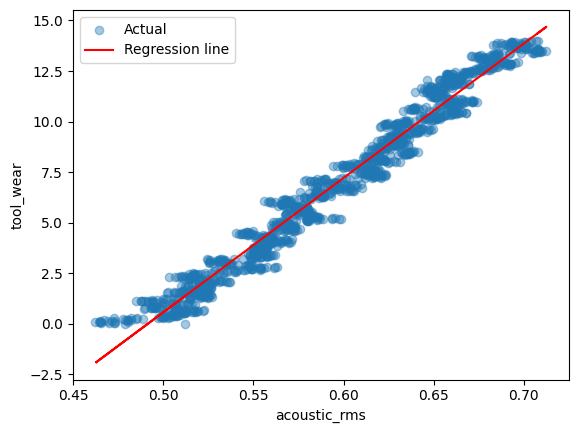

In [30]:
X = df[['mv_avg_ar']]
y = df['tool_wear']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"MAE: {mean_absolute_error(y, y_pred):.3f}")
print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"回帰式: tool_wear = {model.coef_[0]:.4f} * acoustic_rms + {model.intercept_:.4f}")

plt.scatter(X, y, alpha=0.4, label='Actual')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.xlabel('acoustic_rms')
plt.ylabel('tool_wear')
plt.legend()
plt.show()

20回分の加工データの移動平均を取ったデータセットから振動データを削除し、モデルを作成した。評価値はR^2 =0.982, MAE=0.394。

次に"acoustic_rms"のみで単回帰分析を行うと、評価値は、R^2 =0.971, MAE=0.572。

MAEの変化率は、振動データを削除すると+64.2%、"spindle_load"も削除すると+138.2%。

このことから、高精度な予測をしようとすると全てのセンサが必要なことが確認できた。

ただし、振動データと"spindle_load"を両方削除したデータセットから作成されたモデルでもR^2=0.971と非常に高く、高い予測精度を求めなければ、音響センサ(acoustic_rms)のみでも十分予測精度が高いモデルが構築可能。

まとめ

工具摩耗値の予測を高精度にしようとするなら複数の加工データと全てのセンサのデータが必要である。 


加工データの数について、求められる加工精度にもよるため一概には言えないが、データ数5以上であればR^2が0.9以上の非常に予測精度が良いモデルが作成可能。

１回の加工データからの予測ではMAEは1.8〜1.9程度で、振動センサのデータを無くしてもほとんどモデルの予測精度には影響しない。

必要なセンサについて、音響センサだけでも20回分の加工データがあれば十分に精度の良いモデルは作成可能であり、高精度が必要でなければ音響センサのみでもよい。